# Etap I — Akwizycja, Harmonizacja i Preprocessing Danych

Ten notebook realizuje **Etap I** z `realization_plan.md` dla 3 miast (Dublin, Paryż, Warszawa):

1) Inwentarz danych wejściowych (GTFS + warstwy przestrzenne)
2) Walidacja i minimalna normalizacja GTFS (spójny kontrakt tabel)
3) Wczytanie i kontrola CRS/geometrii warstw GIS
4) Zapis spójnych artefaktów do `../outputs/etap1/` + raporty sanity-check

**Założenia (świadome i opisane w raportach):**
- Nie filtrujemy jeszcze GTFS do jednej daty (to będzie osobny pod-etap, jeśli potrzebny).
- Nie poprawiamy agresywnie danych — w Etapie I raportujemy problemy i robimy tylko bezpieczne korekty typów/ID.
- Docelowe CRS metryczne per miasto (do obliczeń w metrach):
  - Dublin: **EPSG:2157** (Irish Transverse Mercator)
  - Warszawa: **EPSG:2180** (ETRS89 / Poland CS92)
  - Paryż: **EPSG:2154** (RGF93 / Lambert-93)

Wyniki: `../outputs/etap1/<city>/...` + raport zbiorczy `../outputs/etap1/summary.md`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Ensure project root is in path for scripts import
ROOT_PATH = Path('..').resolve()
if str(ROOT_PATH) not in sys.path:
    sys.path.insert(0, str(ROOT_PATH))


import json
import os
import platform
import zipfile
from datetime import datetime
from pathlib import Path
from typing import Dict, Iterable, Optional, Tuple

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
from shapely.geometry import box

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 120)

print('Python:', platform.python_version())
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('geopandas:', gpd.__version__)


c:\Users\Michc\Dropbox\IO_UW\Magisterka\Masters\.venv\lib\site-packages\networkx\utils\backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


Python: 3.9.13
pandas: 2.3.3
numpy: 2.0.2
geopandas: 1.0.1


## 0) Konfiguracja ścieżek i miast (kontrakt danych)

In [2]:
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'Data'
VARIANT: str = 'extended'  # Zmień na 'core' dla wariantu rdzeniowego
OUT_DIR = ROOT / 'outputs' / 'etap1' / VARIANT
OUT_DIR.mkdir(parents=True, exist_ok=True)

def _assert_exists(path: Path, label: str) -> None:
    if not path.exists():
        raise FileNotFoundError(f'Missing {label}: {path}')

_assert_exists(DATA_DIR, 'Data directory')
print('ROOT:', ROOT)
print('DATA_DIR:', DATA_DIR)
print('VARIANT:', VARIANT)
print('OUT_DIR:', OUT_DIR)

ROOT: C:\Users\Michc\Dropbox\IO_UW\Magisterka\Masters
DATA_DIR: C:\Users\Michc\Dropbox\IO_UW\Magisterka\Masters\Data
VARIANT: extended
OUT_DIR: C:\Users\Michc\Dropbox\IO_UW\Magisterka\Masters\outputs\etap1\extended


In [3]:
CITY_CFG = {
    'dublin': {
        'prefix': 'DUB_',
        'gtfs_zip': DATA_DIR / 'Dublin' / 'GTFS_Realtime2.zip',
        'osm_pbf': DATA_DIR / 'Dublin' / 'ireland-and-northern-ireland-latest.osm.pbf',
        'spatial': {
            'grid_1km': DATA_DIR / 'Dublin' / 'Grid_IE_1km_ITM' / 'Grid_IE_1km_ITM.shp',
            'work_zones': DATA_DIR / 'Dublin' / 'Workplace_Zones_ITM' / 'Workplace_Zones_ITM.shp',
        },
        'pop_csv': DATA_DIR / 'Dublin' / 'grid_population_2022_view_-5537592749934750149.csv',  # RC3
        'crs_metric': 'EPSG:2157',
        'boundary_query': ["Dublin City, Ireland"],
        'boundary_query_extended': ["County Dublin, Ireland"],
        # Kontrakt atrybutowy — ułatwia podmianę danych i zapewnia porównywalność między miastami
        'demand_contract': {
            'pop_column': 'pop',             # Census 2022 GISCO grid -> sjoin do ITM grid (RC3)
            'employment_column': 'T8_T',    # Total Industry z SAPS (Workplace Zones)
            'employment_layer': 'work_zones',
            'employment_unit': 'zone',      # Workplace Zones ≠ grid 1km — wymaga areal-weighted aggregation
        },
    },
    'paris': {
        'prefix': 'PAR_',
        'gtfs_zip': DATA_DIR / 'Paris' / 'tdg-80921-202604170039.zip',
        'osm_pbf': DATA_DIR / 'Paris' / 'ile-de-france-260111.osm.pbf',
        'spatial': {
            'employment_zones': OUT_DIR / 'paris' / 'spatial' / 'workplace_density_1km.geojson',
        },
        'tabular_spatial': {
            'pop_grid_xyz': DATA_DIR / 'Paris' / 'fra_pd_2020_1km_ASCII_XYZ.csv',
        },
        'crs_metric': 'EPSG:2154',
        'boundary_query': [
            "Paris, France",
            "Vallée Sud Grand Paris, France",
            "Grand Paris Seine Ouest, France",
            "Paris Ouest La Défense, France",
            "Boucle Nord de Seine, France",
            "Plaine Commune, France",
            "Paris Terres d'Envol, France",
            "Est Ensemble, France",
            "Grand Paris - Grand Est, France",
            "Paris Est Marne et Bois, France",
            "Grand Paris Sud Est Avenir, France",
            "Grand-Orly Seine Bièvre, France"
        ],
        'boundary_query_extended': ["Île-de-France, France"],
        'demand_contract': {
            'pop_column': 'pop',                    # z pop_grid_1km (generowane z CSV XYZ)
            'employment_column': 'workplace_count', # z POLE_EMPLOI.geojson (oparte na SIRENE z workplace density)
            'employment_layer': 'employment_zones',
            'employment_unit': 'zone',              # Mamy gotową siatkę 1km.
                                                            },
    },
    'warsaw': {
        'prefix': 'WAW_',
        'gtfs_zip': DATA_DIR / 'Warsaw' / 'warsaw_merged.zip',
        'gtfs_zip_alternatives': [
            DATA_DIR / 'Warsaw' / 'new_data' / 'warsaw.zip',
            DATA_DIR / 'Warsaw' / 'new_data' / 'polish_trains.zip',
            DATA_DIR / 'Warsaw' / 'new_data' / 'wkd.zip'
        ],
        'osm_pbf': DATA_DIR / 'Warsaw' / 'mazowieckie-260111_v4.osm.pbf',
        'spatial': {
            'grid_1km': DATA_DIR / 'Warsaw' / 'NSP2021. Dane o ludności krajowej w siatce kilometrowej. _ 2021 census data. Population in 1km grid._11_15_2025.geojson',
            'labour_market': DATA_DIR / 'Warsaw' / 'waw_miejsca_pracy' / 'waw_miejsca_pracy.shp',
        },
        'crs_metric': 'EPSG:2180',
        'boundary_query': [
            "Warszawa, Poland"],
        'boundary_query_extended': [
            "Warszawa, Poland",
            "powiat warszawski zachodni, Polska",
            "powiat piaseczyński, Polska",
            "powiat pruszkowski, Polska",
            "powiat legionowski, Polska",
            "powiat wołomiński, Polska",
            "powiat miński, Polska",
            "powiat otwocki, Polska",
        ],
        'demand_contract': {
            'pop_column': 'tot',            # Total population z NSP 2021 grid
            'employment_column': 'miejsca_pr',     # Z modelu Datawise
            'employment_layer': 'labour_market',
            'employment_unit': 'zone',
        },
    },
}

In [4]:
# [NEW] Fetch Administrative Boundaries
print("--- Fetching Administrative Boundaries ---")
for city, cfg in CITY_CFG.items():
    if 'boundary_query' in cfg:
        queries = cfg.get('boundary_query_extended', cfg['boundary_query']) if VARIANT == 'extended' else cfg['boundary_query']
        print(f"[{city}] Querying: {queries}")
        try:
            # Sciezka cache zalezy od wariantu -- core i extended maja odrebne granice administracyjne
            _bname = 'boundary_admin_extended.geojson' if VARIANT == 'extended' else 'boundary_admin.geojson'
            out_path = DATA_DIR / city.capitalize() / _bname
            force_update = False

            if out_path.exists():
                 print(f"[{city}] Loading cached boundary from {out_path}")
                 gdf_boundary = gpd.read_file(out_path)
                 # Heuristic: if we expect multiple regions but get 1, assume dissolved and stale
                 if len(queries) > 1 and len(gdf_boundary) == 1:
                     print(f"[{city}] Cached boundary appears dissolved. Forcing refresh.")
                     force_update = True

            if not out_path.exists() or force_update:
                 gdf_boundary = ox.geocode_to_gdf(queries)
                 # Ensure we keep subdivisions (do not dissolve)
                 out_path.parent.mkdir(parents=True, exist_ok=True)
                 gdf_boundary.to_file(out_path, driver='GeoJSON')
                 print(f"[{city}] Boundary saved to {out_path}")

            cfg['boundary_path'] = out_path

        except Exception as e:
            print(f"[{city}] Failed to fetch boundary: {e}")


--- Fetching Administrative Boundaries ---
[dublin] Querying: ['County Dublin, Ireland']
[dublin] Loading cached boundary from C:\Users\Michc\Dropbox\IO_UW\Magisterka\Masters\Data\Dublin\boundary_admin_extended.geojson
[paris] Querying: ['Île-de-France, France']
[paris] Loading cached boundary from C:\Users\Michc\Dropbox\IO_UW\Magisterka\Masters\Data\Paris\boundary_admin_extended.geojson
[warsaw] Querying: ['Warszawa, Poland', 'powiat warszawski zachodni, Polska', 'powiat piaseczyński, Polska', 'powiat pruszkowski, Polska', 'powiat legionowski, Polska', 'powiat wołomiński, Polska', 'powiat miński, Polska', 'powiat otwocki, Polska']
[warsaw] Loading cached boundary from C:\Users\Michc\Dropbox\IO_UW\Magisterka\Masters\Data\Warsaw\boundary_admin_extended.geojson
[warsaw] Cached boundary appears dissolved. Forcing refresh.
[warsaw] Boundary saved to C:\Users\Michc\Dropbox\IO_UW\Magisterka\Masters\Data\Warsaw\boundary_admin_extended.geojson


In [5]:
# Scalanie feedów GTFS (Warszawa: ZTM + KM + WKD + PolRegio)
# Nowa wersja gtfs_merge: diagnostyka per-feed, filtracja dat do intersekcji,
# generacja transferów pieszych między operatorami (max 200m Haversine).
from scripts.gtfs_merge import merge_gtfs_zips
import tempfile
import zipfile
import shutil


def sanitize_warsaw_merged_gtfs(zip_path: Path) -> Dict[str, int]:
    """Naprawa spójności merged GTFS dla R5 (service_id + stop_sequence + referencje)."""
    stats: Dict[str, int] = {
        'trips_before': 0,
        'trips_after': 0,
        'stop_times_before': 0,
        'stop_times_after': 0,
        'routes_before': 0,
        'routes_after': 0,
        'stops_before': 0,
        'stops_after': 0,
        'calendar_dates_before': 0,
        'calendar_dates_after': 0,
        'calendar_before': 0,
        'calendar_after': 0,
        'stop_sequence_reindexed': 0,
    }

    if not zip_path.exists():
        raise FileNotFoundError(zip_path)

    with tempfile.TemporaryDirectory() as td:
        tmp_dir = Path(td)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(tmp_dir)

        def _read_csv(name: str) -> Optional[pd.DataFrame]:
            p = tmp_dir / name
            if not p.exists():
                return None
            return pd.read_csv(p, dtype='string', low_memory=False)

        def _write_csv(name: str, df: pd.DataFrame):
            df.to_csv(tmp_dir / name, index=False)

        trips = _read_csv('trips.txt')
        stop_times = _read_csv('stop_times.txt')
        routes = _read_csv('routes.txt')
        stops = _read_csv('stops.txt')
        calendar = _read_csv('calendar.txt')
        calendar_dates = _read_csv('calendar_dates.txt')

        if trips is None or stop_times is None:
            raise ValueError(f'{zip_path.name}: missing trips.txt or stop_times.txt')

        stats['trips_before'] = int(len(trips))
        stats['stop_times_before'] = int(len(stop_times))
        stats['routes_before'] = int(len(routes)) if routes is not None else 0
        stats['stops_before'] = int(len(stops)) if stops is not None else 0
        stats['calendar_before'] = int(len(calendar)) if calendar is not None else 0
        stats['calendar_dates_before'] = int(len(calendar_dates)) if calendar_dates is not None else 0

        # 1) service_id spójne z calendar/calendar_dates
        valid_services = set()
        if calendar is not None and 'service_id' in calendar.columns:
            valid_services |= set(calendar['service_id'].dropna().astype('string'))
        if calendar_dates is not None and 'service_id' in calendar_dates.columns:
            valid_services |= set(calendar_dates['service_id'].dropna().astype('string'))

        if valid_services and 'service_id' in trips.columns:
            trips = trips[trips['service_id'].isin(valid_services)].copy()

        # 2) stop_times tylko dla istniejących trip_id
        valid_trip_ids = set(trips['trip_id'].dropna().astype('string')) if 'trip_id' in trips.columns else set()
        if 'trip_id' in stop_times.columns and valid_trip_ids:
            stop_times = stop_times[stop_times['trip_id'].isin(valid_trip_ids)].copy()

        # 3) Naprawa stop_sequence do zakresu 1..N per trip, gdy są zera/NaN/duplikaty
        if {'trip_id', 'stop_sequence'}.issubset(stop_times.columns):
            seq_num = pd.to_numeric(stop_times['stop_sequence'], errors='coerce')
            need_reindex = bool(
                (seq_num <= 0).any() or
                seq_num.isna().any() or
                stop_times.duplicated(subset=['trip_id', 'stop_sequence']).any()
            )
            if need_reindex:
                stop_times['_seq_num'] = seq_num
                sort_cols = [c for c in ['trip_id', '_seq_num', 'arrival_time', 'departure_time', 'stop_id'] if c in stop_times.columns]
                stop_times = stop_times.sort_values(sort_cols, kind='mergesort')
                stop_times['stop_sequence'] = (stop_times.groupby('trip_id').cumcount() + 1).astype('string')
                stop_times = stop_times.drop(columns=['_seq_num'])
                stats['stop_sequence_reindexed'] = 1

        # 4) routes/stops referencyjnie do stop_times/trips
        if routes is not None and {'route_id'}.issubset(routes.columns) and {'route_id'}.issubset(trips.columns):
            valid_routes = set(trips['route_id'].dropna().astype('string'))
            routes = routes[routes['route_id'].isin(valid_routes)].copy()

        if stops is not None and {'stop_id'}.issubset(stops.columns) and {'stop_id'}.issubset(stop_times.columns):
            valid_stops = set(stop_times['stop_id'].dropna().astype('string'))
            stops = stops[stops['stop_id'].isin(valid_stops)].copy()

        # 5) calendar/calendar_dates tylko dla service_id istniejących po filtrowaniu trips
        if 'service_id' in trips.columns:
            used_services = set(trips['service_id'].dropna().astype('string'))
            if calendar is not None and 'service_id' in calendar.columns:
                calendar = calendar[calendar['service_id'].isin(used_services)].copy()
            if calendar_dates is not None and 'service_id' in calendar_dates.columns:
                calendar_dates = calendar_dates[calendar_dates['service_id'].isin(used_services)].copy()

        # Zapis tabel
        _write_csv('trips.txt', trips)
        _write_csv('stop_times.txt', stop_times)
        if routes is not None:
            _write_csv('routes.txt', routes)
        if stops is not None:
            _write_csv('stops.txt', stops)
        if calendar is not None:
            _write_csv('calendar.txt', calendar)
        if calendar_dates is not None:
            _write_csv('calendar_dates.txt', calendar_dates)

        stats['trips_after'] = int(len(trips))
        stats['stop_times_after'] = int(len(stop_times))
        stats['routes_after'] = int(len(routes)) if routes is not None else 0
        stats['stops_after'] = int(len(stops)) if stops is not None else 0
        stats['calendar_after'] = int(len(calendar)) if calendar is not None else 0
        stats['calendar_dates_after'] = int(len(calendar_dates)) if calendar_dates is not None else 0

        # Repack ZIP atomowo
        tmp_zip = zip_path.with_suffix('.tmp.zip')
        with zipfile.ZipFile(tmp_zip, 'w', compression=zipfile.ZIP_DEFLATED) as z:
            for p in sorted(tmp_dir.rglob('*')):
                if p.is_file():
                    z.write(p, arcname=p.relative_to(tmp_dir).as_posix())

        if zip_path.exists():
            zip_path.unlink()
        tmp_zip.replace(zip_path)

    return stats


merge_results = {}
for city, cfg in CITY_CFG.items():
    if 'gtfs_zip_alternatives' not in cfg:
        continue
    out_path = cfg['gtfs_zip']
    print(f"[{city}] Merging GTFS feeds into {out_path}...")
    try:
        stats = merge_gtfs_zips(
            cfg['gtfs_zip_alternatives'],
            out_path,
            generate_inter_feed_transfers=True,
            transfer_max_distance_m=200.0,
            filter_dates_to_intersection=True,
        )

        # Dodatkowy krok stabilizacji dla R5: spójność service_id i stop_sequence
        if city.startswith('warsaw'):
            s = sanitize_warsaw_merged_gtfs(out_path)
            print(
                f"[{city}] Post-merge sanitize: "
                f"trips {s['trips_before']}->{s['trips_after']}, "
                f"stop_times {s['stop_times_before']}->{s['stop_times_after']}, "
                f"routes {s['routes_before']}->{s['routes_after']}, "
                f"stops {s['stops_before']}->{s['stops_after']}, "
                f"calendar_dates {s['calendar_dates_before']}->{s['calendar_dates_after']}, "
                f"stop_sequence_reindexed={bool(s['stop_sequence_reindexed'])}"
            )

        merge_results[city] = stats
        print(f"[{city}] Merge complete. Tables: {len(stats.tables_written)}, "
              f"date intersection: {stats.date_intersection}, "
              f"inter-feed transfers generated: {stats.transfers_generated}")
        # Podsumowanie diagnostyk per feed
        for diag in stats.feed_diagnostics:
            print(f"  [{diag.prefix}] stops={diag.n_stops}, routes={diag.n_routes}, "
                  f"trips={diag.n_trips}, dates={diag.date_min}–{diag.date_max}, "
                  f"type={diag.calendar_type}")
    except Exception as e:
        print(f"[{city}] Merge FAILED: {e}")
        import traceback; traceback.print_exc()


[warsaw] Merging GTFS feeds into C:\Users\Michc\Dropbox\IO_UW\Magisterka\Masters\Data\Warsaw\warsaw_merged.zip...
  [MERGE] calendar_dates.txt: przefiltrowano 48519 -> 17477 wpisów do intersekcji dat.
  [MERGE] Wygenerowano 922 transferów pieszych między operatorami (max. 200.0m).
[warsaw] Post-merge sanitize: trips 344429->341600, stop_times 8560923->8517039, routes 510->510, stops 10452->10129, calendar_dates 17477->17477, stop_sequence_reindexed=True
[warsaw] Merge complete. Tables: 12, date intersection: ('20260422', '20260522'), inter-feed transfers generated: 922
  [warsaw] stops=7232, routes=328, trips=318589, dates=20260422–20260522, type=calendar_dates
  [polish_trains] stops=3190, routes=180, trips=24076, dates=20251214–20260613, type=calendar_dates
  [wkd] stops=30, routes=2, trips=1764, dates=20251214–20260629, type=calendar_dates


In [6]:
run_info = {
    'run_utc': datetime.utcnow().isoformat(timespec='seconds') + 'Z',
    'root': str(ROOT),
    'data_dir': str(DATA_DIR),
    'out_dir': str(OUT_DIR),
    'cities': list(CITY_CFG.keys()),
    'versions': {
        'python': platform.python_version(),
        'pandas': pd.__version__,
        'numpy': np.__version__,
        'geopandas': gpd.__version__,
    },
}
(OUT_DIR / 'run_info.json').write_text(json.dumps(run_info, ensure_ascii=False, indent=2), encoding='utf-8')

inventory_rows = []
for city, cfg in CITY_CFG.items():
    inventory_rows.append({'city': city, 'type': 'gtfs_zip', 'name': 'gtfs', 'path': str(cfg['gtfs_zip']), 'exists': cfg['gtfs_zip'].exists()})
    for layer_name, layer_path in cfg['spatial'].items():
        inventory_rows.append({'city': city, 'type': 'spatial', 'name': layer_name, 'path': str(layer_path), 'exists': layer_path.exists()})

inventory_df = pd.DataFrame(inventory_rows)
inventory_df.to_csv(OUT_DIR / 'inventory.csv', index=False)
inventory_df


,city,type,name,path,exists
0,dublin,gtfs_zip,gtfs,C:\Users\Michc\Dropbox\IO_UW\Magisterka\Master...,True
1,dublin,spatial,grid_1km,C:\Users\Michc\Dropbox\IO_UW\Magisterka\Master...,True
2,dublin,spatial,work_zones,C:\Users\Michc\Dropbox\IO_UW\Magisterka\Master...,True
3,paris,gtfs_zip,gtfs,C:\Users\Michc\Dropbox\IO_UW\Magisterka\Master...,True
4,paris,spatial,employment_zones,C:\Users\Michc\Dropbox\IO_UW\Magisterka\Master...,True
5,warsaw,gtfs_zip,gtfs,C:\Users\Michc\Dropbox\IO_UW\Magisterka\Master...,True
6,warsaw,spatial,grid_1km,C:\Users\Michc\Dropbox\IO_UW\Magisterka\Master...,True
7,warsaw,spatial,labour_market,C:\Users\Michc\Dropbox\IO_UW\Magisterka\Master...,True


## 2) Funkcje pomocnicze — GTFS

Kontrakt minimalny po normalizacji (wspólny dla miast):
- `stops`: `stop_id`, `stop_name`, `stop_lat`, `stop_lon`
- `routes`: `route_id`, `route_type` (jeśli jest)
- `trips`: `trip_id`, `route_id`, `service_id` (jeśli jest), `shape_id` (jeśli jest)
- `stop_times`: `trip_id`, `stop_id`, `stop_sequence`, `arrival_time`, `departure_time`

Dodatkowe tabele (opcjonalne) zapisujemy, jeśli istnieją (np. `calendar`, `calendar_dates`, `frequencies`, `transfers`, `pathways`, `shapes`).

In [7]:
def get_osm_pbf_bounds(pbf_path: Path) -> Optional[tuple[float, float, float, float]]:
    """Extracts the bounding box from an OSM PBF header using osmium.

    Returns:
        (min_lon, min_lat, max_lon, max_lat) or None if not found/error.
    """
    if not pbf_path.exists():
        return None
    try:
        import osmium  # lazy import — nie wymaga instalacji jeśli nie używamy
        f = osmium.io.Reader(str(pbf_path))
        h = f.header()
        b = h.box()
        return (b.bottom_left.lon, b.bottom_left.lat, b.top_right.lon, b.top_right.lat)
    except ImportError:
        print(f"Warning: osmium not installed, cannot read OSM bounds from {pbf_path}")
        return None
    except Exception as e:
        print(f"Warning: could not read OSM bounds from {pbf_path}: {e}")
        return None

def filter_gtfs_by_bbox(gtfs: Dict[str, pd.DataFrame], bbox: tuple[float, float, float, float]) -> Dict[str, pd.DataFrame]:
    """Filters GTFS content to keep only stops within the bounding box."""
    if 'stops' not in gtfs:
        return gtfs

    min_x, min_y, max_x, max_y = bbox
    stops = gtfs['stops']

    if not pd.api.types.is_numeric_dtype(stops['stop_lon']):
         stops['stop_lon'] = pd.to_numeric(stops['stop_lon'], errors='coerce')
    if not pd.api.types.is_numeric_dtype(stops['stop_lat']):
         stops['stop_lat'] = pd.to_numeric(stops['stop_lat'], errors='coerce')

    mask = (
        (stops['stop_lon'] >= min_x) &
        (stops['stop_lon'] <= max_x) &
        (stops['stop_lat'] >= min_y) &
        (stops['stop_lat'] <= max_y)
    )
    
    print(f"  [BBOX Filter] Stops: {len(stops)} -> {int(mask.sum())} ({(mask.sum()/len(stops)):.1%})")
    
    if mask.sum() == len(stops):
        return gtfs
    
    return _apply_stop_filter(gtfs, stops[mask].copy())

def filter_gtfs_by_polygon(gtfs: Dict[str, pd.DataFrame], polygon_gdf: gpd.GeoDataFrame) -> Dict[str, pd.DataFrame]:
    """Filters GTFS to keep only stops within a given GeoDataFrame polygon(s)."""
    if 'stops' not in gtfs:
        return gtfs

    stops = gtfs['stops']
    
    # 1. Ensure stop_lon / stop_lat are numeric
    if not pd.api.types.is_numeric_dtype(stops['stop_lon']):
        stops['stop_lon'] = pd.to_numeric(stops['stop_lon'], errors='coerce')
    if not pd.api.types.is_numeric_dtype(stops['stop_lat']):
        stops['stop_lat'] = pd.to_numeric(stops['stop_lat'], errors='coerce')

    # Drop stops with missing coordinates immediately
    stops = stops.dropna(subset=['stop_lon', 'stop_lat']).copy()
    
    if len(stops) == 0:
        print("  [Polygon Filter] No valid stops to filter.")
        return _apply_stop_filter(gtfs, stops)
    
    # 2. Make Stops GeoDataFrame
    stops_gdf = gpd.GeoDataFrame(
        stops,
        geometry=gpd.points_from_xy(stops['stop_lon'], stops['stop_lat']),
        crs='EPSG:4326'  # GTFS is in WGS84
    )
    
    # 3. Set Boundary CRS safely
    poly_crs = polygon_gdf.crs
    if poly_crs is None:
        print("  [Polygon Filter] Warning: boundary_gdf lacks CRS. Assuming EPSG:4326")
        poly_crs = 'EPSG:4326'
        polygon_gdf.set_crs(poly_crs, inplace=True)
    
    # 4. Project stops to boundary CRS
    stops_gdf_proj = stops_gdf.to_crs(poly_crs)
    
    # 5. Spatial Join
    inside = gpd.sjoin(stops_gdf_proj, polygon_gdf[['geometry']], how='inner', predicate='within')
    
    # Re-extract raw dataframe, drop geometry before feeding back
    valid_stops_df = pd.DataFrame(inside.drop(columns=['geometry', 'index_right'], errors='ignore'))
    
    print(f"  [Polygon Filter] Stops: {len(stops)} -> {len(valid_stops_df)} ({(len(valid_stops_df)/len(stops)):.1%})")

    return _apply_stop_filter(gtfs, valid_stops_df)

def _apply_stop_filter(gtfs: Dict[str, pd.DataFrame], valid_stops_df: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    """Kaskadowe czyszczenie tabel GTFS po usunięciu przystanków.
    
    Kasuje osierocone rekordy: stops → stop_times → trips → routes,
    a także transfers, pathways, frequencies, shapes, calendar/calendar_dates.
    """
    stops = gtfs['stops']

    if len(valid_stops_df) == len(stops):
        return gtfs

    out = gtfs.copy()
    out['stops'] = valid_stops_df
    valid_stop_ids = set(valid_stops_df['stop_id'])

    valid_trip_ids = None
    valid_route_ids = None
    valid_service_ids = None
    valid_shape_ids = None

    # 1) stop_times → trips → routes
    if 'stop_times' in out:
        st = out['stop_times']
        valid_st = st[st['stop_id'].isin(valid_stop_ids)].copy()
        valid_trip_ids = set(valid_st['trip_id'])
        print(f"  [Filter] stop_times: {len(st)} -> {len(valid_st)}")
        out['stop_times'] = valid_st

        if 'trips' in out:
            tr = out['trips']
            valid_tr = tr[tr['trip_id'].isin(valid_trip_ids)].copy()
            print(f"  [Filter] trips: {len(tr)} -> {len(valid_tr)}")
            out['trips'] = valid_tr
            valid_route_ids = set(valid_tr['route_id'])
            if 'service_id' in valid_tr.columns:
                valid_service_ids = set(valid_tr['service_id'])
            if 'shape_id' in valid_tr.columns:
                valid_shape_ids = set(valid_tr['shape_id'].dropna())

            if 'routes' in out:
                rt = out['routes']
                valid_rt = rt[rt['route_id'].isin(valid_route_ids)].copy()
                print(f"  [Filter] routes: {len(rt)} -> {len(valid_rt)}")
                out['routes'] = valid_rt

    # 2) transfers — referencje do stop_id
    if 'transfers' in out:
        tf = out['transfers']
        n_before = len(tf)
        mask = pd.Series(True, index=tf.index)
        if 'from_stop_id' in tf.columns:
            mask &= tf['from_stop_id'].isin(valid_stop_ids)
        if 'to_stop_id' in tf.columns:
            mask &= tf['to_stop_id'].isin(valid_stop_ids)
        out['transfers'] = tf[mask].copy()
        if n_before != len(out['transfers']):
            print(f"  [Filter] transfers: {n_before} -> {len(out['transfers'])}")

    # 3) pathways — referencje do stop_id
    if 'pathways' in out:
        pw = out['pathways']
        n_before = len(pw)
        mask = pd.Series(True, index=pw.index)
        if 'from_stop_id' in pw.columns:
            mask &= pw['from_stop_id'].isin(valid_stop_ids)
        if 'to_stop_id' in pw.columns:
            mask &= pw['to_stop_id'].isin(valid_stop_ids)
        out['pathways'] = pw[mask].copy()
        if n_before != len(out['pathways']):
            print(f"  [Filter] pathways: {n_before} -> {len(out['pathways'])}")

    # 4) frequencies — referencje do trip_id
    if 'frequencies' in out and valid_trip_ids is not None:
        fr = out['frequencies']
        n_before = len(fr)
        out['frequencies'] = fr[fr['trip_id'].isin(valid_trip_ids)].copy()
        if n_before != len(out['frequencies']):
            print(f"  [Filter] frequencies: {n_before} -> {len(out['frequencies'])}")

    # 5) shapes — referencje do shape_id
    if 'shapes' in out and valid_shape_ids is not None:
        sh = out['shapes']
        n_before = len(sh)
        out['shapes'] = sh[sh['shape_id'].isin(valid_shape_ids)].copy()
        if n_before != len(out['shapes']):
            print(f"  [Filter] shapes: {n_before} -> {len(out['shapes'])}")

    # 6) calendar / calendar_dates — referencje do service_id
    if valid_service_ids is not None:
        if 'calendar' in out:
            cal = out['calendar']
            n_before = len(cal)
            out['calendar'] = cal[cal['service_id'].isin(valid_service_ids)].copy()
            if n_before != len(out['calendar']):
                print(f"  [Filter] calendar: {n_before} -> {len(out['calendar'])}")
        if 'calendar_dates' in out:
            cd = out['calendar_dates']
            n_before = len(cd)
            out['calendar_dates'] = cd[cd['service_id'].isin(valid_service_ids)].copy()
            if n_before != len(out['calendar_dates']):
                print(f"  [Filter] calendar_dates: {n_before} -> {len(out['calendar_dates'])}")

    return out

REQUIRED_GTFS_TABLES = ['stops', 'routes', 'trips', 'stop_times']

def read_gtfs_zip(zip_path: Path) -> Dict[str, pd.DataFrame]:
    tables: Dict[str, pd.DataFrame] = {}
    with zipfile.ZipFile(zip_path, 'r') as zf:
        names = [n for n in zf.namelist() if n.lower().endswith('.txt')]
        if not names:
            raise ValueError(f'No .txt files found in GTFS zip: {zip_path}')
        for name in sorted(names):
            base = Path(name).name
            key = base[:-4].lower()
            with zf.open(name) as fp:
                df = pd.read_csv(fp, dtype='string', keep_default_na=False)
            df.columns = [c.strip() for c in df.columns]
            tables[key] = df
    return tables

def validate_gtfs_required_tables(gtfs: Dict[str, pd.DataFrame], required: Iterable[str] = None) -> Dict[str, object]:
    required = REQUIRED_GTFS_TABLES if required is None else list(required)
    present = sorted([t for t in required if t in gtfs])
    missing = sorted([t for t in required if t not in gtfs])
    all_tables = sorted(gtfs.keys())
    return {'present_required': present, 'missing_required': missing, 'all_tables': all_tables}

def _safe_float(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series.astype('string').str.strip().replace({'': pd.NA}), errors='coerce')

def _safe_int(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series.astype('string').str.strip().replace({'': pd.NA}), errors='coerce').astype('Int64')

def normalize_gtfs_tables(gtfs: Dict[str, pd.DataFrame], city_prefix: str) -> Dict[str, pd.DataFrame]:
    out: Dict[str, pd.DataFrame] = {k: v.copy() for k, v in gtfs.items()}
    for table, df in out.items():
        for col in df.columns:
            if col.endswith('_id'):
                s = df[col].astype('string')
                needs = ~s.str.startswith(city_prefix)
                non_empty = s.str.len().fillna(0) > 0
                mask = needs & non_empty
                df.loc[mask, col] = city_prefix + s.loc[mask]
        out[table] = df

    if 'stops' in out:
        s = out['stops']
        if 'stop_lat' in s.columns: s['stop_lat'] = _safe_float(s['stop_lat'])
        if 'stop_lon' in s.columns: s['stop_lon'] = _safe_float(s['stop_lon'])
        out['stops'] = s

    if 'routes' in out:
        r = out['routes']
        if 'route_type' in r.columns: r['route_type'] = _safe_int(r['route_type'])
        out['routes'] = r

    if 'stop_times' in out:
        st = out['stop_times']
        if 'stop_sequence' in st.columns: st['stop_sequence'] = _safe_int(st['stop_sequence'])
        out['stop_times'] = st

    # Usunięcie podróży bez powiązań z kalendarzem (bug r5py bitIndex < 0)
    if 'trips' in out:
        valid_services = set()
        if 'calendar' in out:
            valid_services.update(out['calendar']['service_id'].dropna())
        if 'calendar_dates' in out:
            valid_services.update(out['calendar_dates']['service_id'].dropna())
        if valid_services:
            tr = out['trips']
            n_trips = len(tr)
            out['trips'] = tr[tr['service_id'].isin(valid_services)].copy()
            dropped = n_trips - len(out['trips'])
            if dropped > 0:
                print(f"    [Normalize] Dropped {dropped} trips lacking valid calendar service_id.")
                valid_trips = set(out['trips']['trip_id'])
                if 'stop_times' in out:
                    n_st = len(out['stop_times'])
                    out['stop_times'] = out['stop_times'][out['stop_times']['trip_id'].isin(valid_trips)].copy()
                    print(f"    [Normalize] Dropped {n_st - len(out['stop_times'])} stop_times attached to invalid trips.")

    return out

def _extract_gtfs_date_ranges(gtfs: Dict[str, pd.DataFrame]) -> Dict[str, object]:
    """Ekstrakcja zakresów dat z calendar i calendar_dates — dokumentacja niespójności czasowej."""
    date_info: Dict[str, object] = {}
    if 'calendar' in gtfs:
        cal = gtfs['calendar']
        if 'start_date' in cal.columns and 'end_date' in cal.columns and len(cal) > 0:
            starts = cal['start_date'].astype(str).str.strip()
            ends = cal['end_date'].astype(str).str.strip()
            valid_starts = starts[starts.str.match(r'^\d{8}$')]
            valid_ends = ends[ends.str.match(r'^\d{8}$')]
            if len(valid_starts) > 0 and len(valid_ends) > 0:
                date_info['calendar'] = {
                    'min_start_date': str(valid_starts.min()),
                    'max_end_date': str(valid_ends.max()),
                    'n_services': int(len(cal)),
                }
    if 'calendar_dates' in gtfs:
        cd = gtfs['calendar_dates']
        if 'date' in cd.columns and len(cd) > 0:
            dates = cd['date'].astype(str).str.strip()
            valid_dates = dates[dates.str.match(r'^\d{8}$')]
            if len(valid_dates) > 0:
                exc_types = cd['exception_type'].value_counts().to_dict() if 'exception_type' in cd.columns else {}
                date_info['calendar_dates'] = {
                    'min_date': str(valid_dates.min()),
                    'max_date': str(valid_dates.max()),
                    'n_entries': int(len(cd)),
                    'exception_types': {str(k): int(v) for k, v in exc_types.items()},
                }
    if 'feed_info' in gtfs:
        fi = gtfs['feed_info']
        feed_dates = {}
        if 'feed_start_date' in fi.columns and len(fi) > 0:
            feed_dates['feed_start_date'] = str(fi['feed_start_date'].iloc[0])
        if 'feed_end_date' in fi.columns and len(fi) > 0:
            feed_dates['feed_end_date'] = str(fi['feed_end_date'].iloc[0])
        if feed_dates:
            date_info['feed_info'] = feed_dates
    return date_info

def gtfs_sanity_checks(gtfs_norm: Dict[str, pd.DataFrame]) -> Dict[str, object]:
    report: Dict[str, object] = {}
    report['row_counts'] = {k: int(len(v)) for k, v in gtfs_norm.items()}
    if all(t in gtfs_norm for t in ['stops', 'trips', 'routes', 'stop_times']):
        stops = gtfs_norm['stops']; trips = gtfs_norm['trips']; routes = gtfs_norm['routes']; st = gtfs_norm['stop_times']
        report['coverage'] = {
            'stop_times.stop_id in stops.stop_id': float(st['stop_id'].isin(stops['stop_id']).mean()) if 'stop_id' in st.columns else None,
            'stop_times.trip_id in trips.trip_id': float(st['trip_id'].isin(trips['trip_id']).mean()) if 'trip_id' in st.columns else None,
            'trips.route_id in routes.route_id': float(trips['route_id'].isin(routes['route_id']).mean()) if 'route_id' in trips.columns else None,
        }
        report['stops_coord_nonnull_share'] = {
            'stop_lat': float(stops['stop_lat'].notna().mean()) if 'stop_lat' in stops.columns else None,
            'stop_lon': float(stops['stop_lon'].notna().mean()) if 'stop_lon' in stops.columns else None,
        }
        if {'trip_id', 'stop_sequence'}.issubset(st.columns):
            report['stop_times_duplicate_trip_stop_sequence'] = int(st.duplicated(subset=['trip_id', 'stop_sequence']).sum())
            report['stop_times_stop_sequence_nonnull_share'] = float(st['stop_sequence'].notna().mean())
    # Zakresy dat GTFS — dokumentacja niespójności czasowej (wymaganie z poczatek.tex, Cel 5)
    report['date_ranges'] = _extract_gtfs_date_ranges(gtfs_norm)
    return report

def gtfs_tables_schema(gtfs: Dict[str, pd.DataFrame]) -> Dict[str, object]:
    return {
        k: {'n_rows': int(len(df)), 'columns': list(df.columns), 'dtypes': {c: str(df[c].dtype) for c in df.columns}}
        for k, df in gtfs.items()
    }

def write_gtfs_outputs(city: str, gtfs_raw: Dict[str, pd.DataFrame], gtfs_norm: Dict[str, pd.DataFrame], report: Dict[str, object]) -> Dict[str, str]:
    city_dir = OUT_DIR / city
    (city_dir / 'gtfs_normalized').mkdir(parents=True, exist_ok=True)
    (city_dir / 'gtfs_raw_tables_schema.json').write_text(json.dumps(gtfs_tables_schema(gtfs_raw), ensure_ascii=False, indent=2), encoding='utf-8')
    (city_dir / 'gtfs_report.json').write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding='utf-8')
    written = {}
    for table, df in gtfs_norm.items():
        out_path = city_dir / 'gtfs_normalized' / f'{table}.csv'
        df.to_csv(out_path, index=False)
        written[table] = str(out_path)
    return written

## 3) Funkcje pomocnicze — GIS (warstwy przestrzenne)

Uwaga techniczna: w tym środowisku `geopandas` działa przez `pyogrio` (brak `fiona`), co jest OK dla Shapefile/GeoJSON.
Zapisy realizujemy jako **GeoJSON** (najbardziej przenośne) oraz dodatkowo jako CSV z `WKT` (fallback).

In [8]:
def read_vector(path: Path) -> gpd.GeoDataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    return gpd.read_file(path)

def basic_gis_checks(gdf: gpd.GeoDataFrame) -> Dict[str, object]:
    out: Dict[str, object] = {
        'n_rows': int(len(gdf)),
        'crs': str(gdf.crs) if gdf.crs is not None else None,
        'geom_types': gdf.geometry.geom_type.value_counts(dropna=False).to_dict() if 'geometry' in gdf else {},
    }
    if len(gdf) > 0 and 'geometry' in gdf:
        out['empty_geom_share'] = float(gdf.geometry.is_empty.mean())
        try:
            out['invalid_geom_share'] = float((~gdf.geometry.is_valid).mean())
        except Exception as e:
            out['invalid_geom_share'] = None
            out['invalid_geom_error'] = f'{e.__class__.__name__}: {e}'
        try:
            minx, miny, maxx, maxy = gdf.total_bounds
            out['total_bounds'] = [float(minx), float(miny), float(maxx), float(maxy)]
        except Exception as e:
            out['total_bounds'] = None
            out['bounds_error'] = f'{e.__class__.__name__}: {e}'
    return out

def reproject_to(gdf: gpd.GeoDataFrame, crs_target: str) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        raise ValueError('Input GeoDataFrame has no CRS; cannot reproject safely.')
    if str(gdf.crs) == crs_target:
        return gdf
    return gdf.to_crs(crs_target)

def write_spatial_outputs(city: str, layer_name: str, gdf_raw: gpd.GeoDataFrame, gdf_metric: gpd.GeoDataFrame) -> Dict[str, str]:
    city_dir = OUT_DIR / city
    spatial_dir = city_dir / 'spatial'
    spatial_dir.mkdir(parents=True, exist_ok=True)

    out_paths = {}

    # GeoJSON (raw & metric)
    raw_path = spatial_dir / f'{layer_name}_raw.geojson'
    metric_path = spatial_dir / f'{layer_name}_metric.geojson'
    gdf_raw.to_file(raw_path, driver='GeoJSON')
    gdf_metric.to_file(metric_path, driver='GeoJSON')
    out_paths['raw_geojson'] = str(raw_path)
    out_paths['metric_geojson'] = str(metric_path)

    # Fallback: CSV + WKT (łatwe do dalszego pandas merge)
    csv_path = spatial_dir / f'{layer_name}_metric_wkt.csv'
    tmp = gdf_metric.copy()
    tmp['geometry_wkt'] = tmp.geometry.to_wkt()
    tmp.drop(columns=['geometry']).to_csv(csv_path, index=False)
    out_paths['metric_wkt_csv'] = str(csv_path)

    return out_paths


In [9]:
def build_unified_pop_grid_from_source(
    source_data,
    source_type: str,
    city: str,
    crs_metric: str = 'EPSG:2154',
    boundary_path: Path = None,
    cell_size_m: float = 1000.0,
) -> Dict[str, gpd.GeoDataFrame]:
    """Buduje warstwę populacji 1km dla dowolnego miasta z ujednoliconą logiką GEOSTAT snap.

    Wspólna logika dla Dublin, Paris, Warsaw: snap do siatki GEOSTAT (EPSG:3035),
    budowa kwadratów 1km, reprojekcja do lokalnego CRS metrycznego.

    Parametry:
    -----------
    source_data : Path, pd.DataFrame, or gpd.GeoDataFrame
        - Path (str): ścieżka do CSV XYZ (kolumny X, Y, Z)
        - pd.DataFrame: dane z kolumnami X, Y (lon/lat), Z (pop)
        - gpd.GeoDataFrame: istniejący grid (będzie snap do GEOSTAT)
    
    source_type : str
        - 'xyz_csv': plik CSV z kolumnami X, Y, Z
        - 'geojson_grid': istniejący grid (użyj centroidów)
        - 'dataframe': pd.DataFrame z X, Y, Z
    
    city : str
        Nazwa miasta (dublin, paris, warsaw) — używany do cell_id
    
    crs_metric : str
        Docelowy metryczny CRS dla miasta (np. EPSG:2157 dla Dublina, EPSG:2154 dla Paryża, EPSG:2180 dla Warszawy)
    
    boundary_path : Path, optional
        Granica administracyjna do clipu
    
    cell_size_m : float
        Rozmiar komórki (default 1000m = 1km)

    Zwraca:
    --------
    dict z:
        - cells_metric: GeoDataFrame z komórkami w CRS metrycznym
        - cells_wgs84: GeoDataFrame z komórkami w WGS84
        - n_input: liczba punktów wejściowych
        - n_output: liczba komórek po snap+dedup
    """
    
    if isinstance(source_data, (str, Path)):
        source_path = Path(source_data)
        if source_type == 'xyz_csv':
            df_in = pd.read_csv(source_path)
            missing = [c for c in ['X', 'Y', 'Z'] if c not in df_in.columns]
            if missing:
                raise ValueError(f"[{city}] CSV missing columns: {missing}")
            pts = gpd.GeoDataFrame(
                df_in.rename(columns={'Z': 'pop'}).copy(),
                geometry=gpd.points_from_xy(df_in['X'], df_in['Y']),
                crs='EPSG:4326',
            )
        elif source_type == 'geojson_grid':
            pts_raw = gpd.read_file(source_path)
            # Użyj centroidów istniejącego gridu
            pts = gpd.GeoDataFrame(
                pts_raw[['pop'] if 'pop' in pts_raw.columns else []].copy(),
                geometry=pts_raw.geometry.centroid,
                crs=pts_raw.crs,
            )
            if pts.crs != 'EPSG:4326':
                pts = pts.to_crs('EPSG:4326')
        else:
            raise ValueError(f"Unknown source_type for Path: {source_type}")
    elif isinstance(source_data, pd.DataFrame):
        missing = [c for c in ['X', 'Y', 'Z'] if c not in source_data.columns]
        if missing:
            raise ValueError(f"[{city}] DataFrame missing columns: {missing}")
        df_in = source_data
        pts = gpd.GeoDataFrame(
            df_in.rename(columns={'Z': 'pop'}).copy(),
            geometry=gpd.points_from_xy(df_in['X'], df_in['Y']),
            crs='EPSG:4326',
        )
    elif isinstance(source_data, gpd.GeoDataFrame):
        pts = source_data.copy()
        if pts.crs != 'EPSG:4326':
            pts = pts.to_crs('EPSG:4326')
        if 'pop' not in pts.columns and 'Z' in pts.columns:
            pts['pop'] = pts['Z']
    else:
        raise TypeError(f"source_data must be Path, DataFrame, or GeoDataFrame, got {type(source_data)}")

    n_input = len(pts)
    print(f"  [{city}] Input points: {n_input}")

    # === GEOSTAT snap (EPSG:3035) — wspólny dla wszystkich miast ===
    pts_3035 = pts.to_crs('EPSG:3035')

    # Snap do siatki GEOSTAT 1km: centroid komórki = floor(x/1000)*1000 + 500
    snap_x = (np.floor(pts_3035.geometry.x.values / 1000.0) * 1000 + 500).astype('int64')
    snap_y = (np.floor(pts_3035.geometry.y.values / 1000.0) * 1000 + 500).astype('int64')

    # Deduplikacja: suma populacji dla punktów trafiających do tej samej komórki GEOSTAT
    df_snap = pts.drop(columns=['geometry']).copy()
    df_snap['snap_x'] = snap_x
    df_snap['snap_y'] = snap_y
    df_agg = df_snap.groupby(['snap_x', 'snap_y'], as_index=False).agg({'pop': 'sum'})
    
    n_output = len(df_agg)
    print(f"  [{city}] After GEOSTAT snap+dedup: {n_output} cells")

    # === Budowa kwadratów w EPSG:3035, reprojekcja do lokalnego CRS metrycznego ===
    half_size = cell_size_m / 2.0
    geoms_3035 = [
        box(x - half_size, y - half_size, x + half_size, y + half_size)
        for x, y in zip(df_agg['snap_x'], df_agg['snap_y'])
    ]
    cells_3035 = gpd.GeoDataFrame(
        df_agg,
        geometry=geoms_3035,
        crs='EPSG:3035',
    )
    cells_metric = cells_3035.to_crs(crs_metric)
    cells_wgs84 = cells_3035.to_crs('EPSG:4326')

    # Identyfikatory komórek na bazie współrzędnych metrycznych centroidów
    cx = np.round(cells_metric.geometry.centroid.x.values, 0).astype('int64')
    cy = np.round(cells_metric.geometry.centroid.y.values, 0).astype('int64')
    cells_metric['cell_id'] = pd.Series(
        [f"{city.upper()}_GRID_{x}_{y}" for x, y in zip(cx, cy)],
        dtype='string'
    )

    # === Clip do granic administracyjnych (jeśli dostarczone) ===
    if boundary_path and Path(boundary_path).exists():
        boundary = gpd.read_file(boundary_path).to_crs(crs_metric)
        boundary_union = boundary.dissolve()
        
        centroids = cells_metric.copy()
        centroids.geometry = centroids.geometry.centroid
        
        n_before = len(cells_metric)
        inside = gpd.sjoin(centroids, boundary_union[['geometry']], how='inner', predicate='within')
        valid_idx = inside.index.unique()
        cells_metric = cells_metric.loc[cells_metric.index.isin(valid_idx)].copy()
        cells_wgs84 = cells_wgs84.loc[cells_wgs84.index.isin(valid_idx)].copy()
        
        print(f"  [{city}] After boundary clip: {len(cells_metric)}/{n_before} cells ({len(cells_metric)/n_before:.1%} kept)")

    # Standardowe kolumny
    keep_cols = ['cell_id', 'pop', 'X', 'Y'] if 'X' in cells_metric.columns else ['cell_id', 'pop']
    for c in keep_cols:
        if c not in cells_metric.columns:
            cells_metric[c] = pd.NA
    cells_metric = cells_metric[keep_cols + ['geometry']]

    return {
        'cells_metric': cells_metric,
        'cells_wgs84': cells_wgs84,
        'n_input': n_input,
        'n_output': n_output,
    }


In [10]:
# === Przykład użycia build_unified_pop_grid_from_source ===
# Wspólna logika GEOSTAT snap dla wszystkich trzech miast z indywidualnymi EPSG

print("=" * 70)
print("UNIFIED POPULATION GRID BUILDER - Wspólna logika dla wszystkich miast")
print("=" * 70)

# Konfiguracja dla każdego miasta
_boundary_filename = 'boundary_admin_extended.geojson' if VARIANT == 'extended' else 'boundary_admin.geojson'
UNIFIED_GRID_CONFIG = {
    'paris': {
        'source_data': DATA_DIR / 'Paris' / 'fra_pd_2020_1km_ASCII_XYZ.csv',
        'source_type': 'xyz_csv',
        'crs_metric': 'EPSG:2154',  # RGF93 / Lambert-93
        'boundary_path': DATA_DIR / 'Paris' / _boundary_filename,
    },
    'dublin': {
        'source_data': DATA_DIR / 'Dublin' / 'grid_population_2022_view_-5537592749934750149.csv',
        'source_type': 'xyz_csv',  # Przygotuj CSV z X, Y, Z jeśli potrzebny
        'crs_metric': 'EPSG:2157',  # ITM (Irish Transverse Mercator)
        'boundary_path': DATA_DIR / 'Dublin' / _boundary_filename,
    },
    'warsaw': {
        'source_data': DATA_DIR / 'Warsaw' / 'NSP2021. Dane o ludności krajowej w siatce kilometrowej. _ 2021 census data. Population in 1km grid._11_15_2025.geojson',
        'source_type': 'geojson_grid',  # Istniejący grid — snap do GEOSTAT
        'crs_metric': 'EPSG:2180',  # ETRS89 / Poland CS92
        'boundary_path': DATA_DIR / 'Warsaw' / _boundary_filename,
    }
}

# Test na Paryżu (już zadziałane)
print("\n[TEST] Building unified grid for PARIS...")
paris_result = build_unified_pop_grid_from_source(
    source_data=UNIFIED_GRID_CONFIG['paris']['source_data'],
    source_type=UNIFIED_GRID_CONFIG['paris']['source_type'],
    city='paris',
    crs_metric=UNIFIED_GRID_CONFIG['paris']['crs_metric'],
    boundary_path=UNIFIED_GRID_CONFIG['paris']['boundary_path'],
)
print(f"✓ Paris grid built: {len(paris_result['cells_metric'])} cells")
print(f"  Total population: {paris_result['cells_metric']['pop'].sum():,.0f}")

# Jeśli chcesz zastosować do Dublina i Warszawy, użyj analogicznie:
# dublin_result = build_unified_pop_grid_from_source(...)
# warsaw_result = build_unified_pop_grid_from_source(...)


UNIFIED POPULATION GRID BUILDER - Wspólna logika dla wszystkich miast

[TEST] Building unified grid for PARIS...
  [paris] Input points: 932764
  [paris] After GEOSTAT snap+dedup: 552789 cells
  [paris] After boundary clip: 12075/552789 cells (2.2% kept)
✓ Paris grid built: 12075 cells
  Total population: 22,579,030


## 4) GTFS — Dublin / Paryż / Warszawa (load → validate → normalize → export)

In [11]:
def process_city_gtfs(city: str) -> Dict[str, object]:
    cfg = CITY_CFG[city]
    zip_path: Path = cfg['gtfs_zip']
    prefix: str = cfg['prefix']

    gtfs_raw = read_gtfs_zip(zip_path)
    validation = validate_gtfs_required_tables(gtfs_raw)
    if validation['missing_required']:
        raise ValueError(f"{city}: missing required GTFS tables: {validation['missing_required']}")

    gtfs_norm = normalize_gtfs_tables(gtfs_raw, city_prefix=prefix)

    # [NEW] Filter by Boundary (Admin) or OSM Bounds
    boundary_path = cfg.get('boundary_path')
    osm_path = cfg.get('osm_pbf')

    if boundary_path and boundary_path.exists():
        print(f"[{city}] Filtering GTFS by Admin Boundary: {boundary_path}")
        gdf_boundary = gpd.read_file(boundary_path)
        gtfs_norm = filter_gtfs_by_polygon(gtfs_norm, gdf_boundary)
    elif osm_path:
        bbox = get_osm_pbf_bounds(osm_path)
        if bbox:
            print(f"[{city}] Filtering GTFS by bbox: {bbox}")
            gtfs_norm = filter_gtfs_by_bbox(gtfs_norm, bbox)
        else:
             print(f"[{city}] Warning: Could not determine bounds, skipping spatial filter.")
    else:
        print(f"[{city}] Warning: No boundary or OSM path found, skipping spatial filter.")

    sanity = gtfs_sanity_checks(gtfs_norm)

    report = {
        'city': city,
        'gtfs_zip': str(zip_path),
        'osm_pbf': str(osm_path) if osm_path else None,
        'boundary_path': str(boundary_path) if boundary_path else None,
        'validation': validation,
        'sanity': sanity,
    }

    written = write_gtfs_outputs(city, gtfs_raw, gtfs_norm, report)

    return {'report': report, 'written_tables': written}

gtfs_results = {}
for city in CITY_CFG.keys():
    print(f'--- Processing GTFS: {city} ---')
    res = process_city_gtfs(city)
    gtfs_results[city] = res
    print('tables written:', len(res['written_tables']))

# szybki podgląd metryk
pd.DataFrame({
    city: gtfs_results[city]['report']['sanity']['row_counts']
    for city in gtfs_results
}).T


--- Processing GTFS: dublin ---
[dublin] Filtering GTFS by Admin Boundary: C:\Users\Michc\Dropbox\IO_UW\Magisterka\Masters\Data\Dublin\boundary_admin_extended.geojson
  [Polygon Filter] Stops: 10242 -> 4801 (46.9%)
  [Filter] stop_times: 7071601 -> 4247994
  [Filter] trips: 195997 -> 101861
  [Filter] routes: 411 -> 216
  [Filter] shapes: 6406589 -> 2778338
  [Filter] calendar: 132 -> 113
  [Filter] calendar_dates: 259 -> 218
tables written: 9
--- Processing GTFS: paris ---
[paris] Filtering GTFS by Admin Boundary: C:\Users\Michc\Dropbox\IO_UW\Magisterka\Masters\Data\Paris\boundary_admin_extended.geojson
  [Polygon Filter] Stops: 54016 -> 53556 (99.1%)
  [Filter] stop_times: 12510816 -> 12493755
  [Filter] trips: 562228 -> 562228
  [Filter] routes: 2008 -> 2008
  [Filter] transfers: 206732 -> 206172
  [Filter] pathways: 5758 -> 5648
tables written: 14
--- Processing GTFS: warsaw ---
[warsaw] Filtering GTFS by Admin Boundary: C:\Users\Michc\Dropbox\IO_UW\Magisterka\Masters\Data\Warsaw\b

,agency,calendar,calendar_dates,feed_info,routes,shapes,stop_times,stops,trips,attributions,booking_rules,object_codes_extension,pathways,ticketing_deep_links,transfers,fare_attributes,fare_rules,frequencies
dublin,7.0,113.0,218.0,1.0,216.0,2778338.0,4247994.0,4801.0,101861.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
paris,61.0,1382.0,4294.0,NaN,2008.0,3558537.0,12493755.0,53556.0,562228.0,2008.0,15.0,1350401.0,5648.0,1.0,206172.0,NaN,NaN,NaN
warsaw,16.0,NaN,9592.0,1.0,379.0,1741496.0,8137969.0,6995.0,325168.0,3.0,NaN,NaN,NaN,NaN,1064.0,82.0,12554.0,101.0


### Szybki sanity-check: kluczowe pokrycia referencji (GTFS)

In [12]:
cov_rows = []
for city in gtfs_results:
    cov = gtfs_results[city]['report']['sanity'].get('coverage', {})
    cov_rows.append({'city': city, **cov})
pd.DataFrame(cov_rows)


,city,stop_times.stop_id in stops.stop_id,stop_times.trip_id in trips.trip_id,trips.route_id in routes.route_id
0,dublin,1.0,1.0,1.0
1,paris,1.0,1.0,1.0
2,warsaw,1.0,1.0,1.0


## 5) GIS — wczytanie warstw, kontrola CRS, reprojekcja do CRS metrycznego, eksport

In [13]:
# --- Helpery ścieżek (używane też w komórce artefaktów) ---
def _rel(path_str: str) -> str:
    """Konwertuje ścieżkę absolutną na względną względem ROOT — portowalność między maszynami."""
    try:
        return str(Path(path_str).relative_to(ROOT))
    except ValueError:
        return path_str

def _relativize_dict(d):
    """Rekursywnie zamienia wartości string wyglądające na ścieżki na względne."""
    if isinstance(d, dict):
        return {k: _relativize_dict(v) for k, v in d.items()}
    elif isinstance(d, str) and (('/' in d or '\\' in d) and ('outputs' in d or 'Data' in d)):
        return _rel(d)
    elif isinstance(d, list):
        return [_relativize_dict(i) for i in d]
    return d

def build_paris_pop_grid_from_xyz(
    csv_path: Path,
    crs_in: str = 'EPSG:4326',
    crs_metric: str = 'EPSG:2154',
    cell_size_m: float = 1000.0,
) -> Dict[str, gpd.GeoDataFrame]:
    """Buduje warstwę populacji 1km dla Paryża z pliku XYZ.

    Kontrakt wejścia (CSV): kolumny X, Y, Z.
    - X: lon
    - Y: lat
    - Z: populacja

    Zwraca:
    - points_raw: punkty (CRS wejściowy)
    - cells_metric: poligony kwadratów 1km (CRS metryczny)
    """
    df = pd.read_csv(csv_path)

    missing = [c for c in ['X', 'Y', 'Z'] if c not in df.columns]
    if missing:
        raise ValueError(f'Paris pop CSV missing columns: {missing}. Got: {list(df.columns)}')

    pts = gpd.GeoDataFrame(
        df.rename(columns={'Z': 'pop'}).copy(),
        geometry=gpd.points_from_xy(df['X'], df['Y']),
        crs=crs_in,
    )

    # CSV fra_pd_2020_1km_ASCII_XYZ.csv to raster 30-arcsecond (~610m×928m ≈ 0.566 km²
    # per komórka) — NIE jest to siatka GEOSTAT 1km×1km. Centroidy WGS84 należą
    # do ~1.77 różnych komórek WGS84 na 1 km² GEOSTAT. Aby uzyskać właściwe
    # kwadraty 1km×1km bez nakładania, stosujemy:
    #   1. Reprojekcja centroidów WGS84 -> EPSG:3035 (natywna siatka GEOSTAT)
    #   2. Snap do siatki GEOSTAT: snap_x = floor(x/1000)*1000 + 500
    #   3. Deduplikacja (wiele WGS84 -> 1 GEOSTAT), populacja = suma
    #   4. Budowa kwadratów 1000m×1000m w EPSG:3035
    #   5. Reprojekcja do crs_metric (EPSG:2154)
    # Wynik: ~815 komórek dla MGP (814 km²), każda ~1.0 km², bez nakładania.
    pts_3035 = pts.to_crs("EPSG:3035")

    # Snap do siatki GEOSTAT 1km (centroid komorki = floor(x/1000)*1000 + 500)
    snap_x = (np.floor(pts_3035.geometry.x.values / 1000.0) * 1000 + 500).astype("int64")
    snap_y = (np.floor(pts_3035.geometry.y.values / 1000.0) * 1000 + 500).astype("int64")

    # Deduplikacja: wiele centroidow WGS84 moze trafic do tej samej komorki GEOSTAT
    df_snap = pts.drop(columns=['geometry']).copy()
    df_snap['snap_x'] = snap_x
    df_snap['snap_y'] = snap_y
    df_agg = df_snap.groupby(['snap_x', 'snap_y'], as_index=False).agg({'pop': 'sum'})
    print(f"  [Paris grid] WGS84 punktow: {len(pts)}, po snap+dedup do GEOSTAT 1km: {len(df_agg)}")

    # Budowa kwadratow 1000m x 1000m w EPSG:3035, reprojekcja do crs_metric
    half_size = cell_size_m / 2.0
    geoms_3035 = [
        box(x - half_size, y - half_size, x + half_size, y + half_size)
        for x, y in zip(df_agg['snap_x'], df_agg['snap_y'])
    ]
    cells_3035 = gpd.GeoDataFrame(
        df_agg,
        geometry=geoms_3035,
        crs="EPSG:3035",
    )
    cells = cells_3035.to_crs(crs_metric)

        # Identyfikatory komórek — na podstawie współrzędnych metrycznych centroidów
    cx = np.round(cells.geometry.centroid.x.values, 0).astype('int64')
    cy = np.round(cells.geometry.centroid.y.values, 0).astype('int64')
    cells['cell_id'] = pd.Series([f'PAR_GRID_{x}_{y}' for x, y in zip(cx, cy)], dtype='string')

    keep_cols = ['cell_id', 'pop', 'X', 'Y']
    for c in keep_cols:
        if c not in cells.columns:
            cells[c] = pd.NA
    cells = cells[keep_cols + ['geometry']]

    return {
        'points_raw': pts,
        'cells_metric': cells,
    }

def aggregate_population_to_dublin_grid(
    grid: gpd.GeoDataFrame,
    pop_csv: Path,
) -> gpd.GeoDataFrame:
    """Dołącza dane populacji Census 2022 (GISCO EPSG:3035) do gridu ITM Dublin (RC3).

    Strategia:
    1. Parse CELLCODE (EEA) 1kmExxxxNyyyy -> centroid EPSG:3035 = (x*1000+500, y*1000+500)
    2. Reprojekcja punktów centroidów do CRS gridu (EPSG:2157)
    3. sjoin(predicate='within'): punkt GISCO wewnątrz wieloboku ITM
    4. Suma populacji per komórka ITM (index_right) -> kolumna 'pop'

    Pokrycie: ~89.6% komórek ITM (~97.4% populacji Irlandii wg Census 2022).
    """
    import re as _re

    df = pd.read_csv(pop_csv)

    def _parse(code: str):
        m = _re.match(r'1kmE(\d+)N(\d+)', str(code))
        return (int(m.group(1)) * 1000 + 500, int(m.group(2)) * 1000 + 500) if m else (None, None)

    coords = df['CELLCODE (EEA)'].apply(lambda c: pd.Series(_parse(c), index=['E3035', 'N3035']))
    df = pd.concat([df, coords], axis=1).dropna(subset=['E3035', 'N3035'])

    gdf_pop = gpd.GeoDataFrame(
        df[['Population2022 (Numeric)']].copy(),
        geometry=gpd.points_from_xy(df['E3035'], df['N3035']),
        crs='EPSG:3035',
    )
    gdf_pop = gdf_pop.to_crs(grid.crs)

    joined  = gpd.sjoin(gdf_pop, grid[['geometry']], how='inner', predicate='within')
    pop_agg = joined.groupby('index_right')['Population2022 (Numeric)'].sum()

    grid_out = grid.copy()
    grid_out['pop'] = pop_agg.reindex(grid_out.index).fillna(0.0)

    matched   = int(grid_out['pop'].gt(0).sum())
    total_pop = grid_out['pop'].sum()
    print(f'  [Dublin pop] {matched}/{len(grid_out)} komórek ({matched/len(grid_out):.1%}), pop={total_pop:,.0f}')
    return grid_out


def clip_to_boundary(gdf: gpd.GeoDataFrame, boundary_path: Path, crs_metric: str) -> gpd.GeoDataFrame:
    """Przycina GeoDataFrame do granic administracyjnych (R1).
    
    Używa centroidów — komórka jest zachowana jeśli jej centroid leży wewnątrz granicy.
    Podejście centroidowe jest szybkie i deterministyczne (nie zmienia geometrii komórek).
    """
    if not boundary_path.exists():
        print(f"  [Clip] Boundary not found: {boundary_path}, skipping clip.")
        return gdf
    
    boundary = gpd.read_file(boundary_path).to_crs(crs_metric)
    boundary_union = boundary.dissolve()
    
    n_before = len(gdf)
    centroids = gdf.copy()
    centroids['_centroid'] = centroids.geometry.centroid
    centroids = centroids.set_geometry('_centroid')
    
    inside = gpd.sjoin(centroids, boundary_union[['geometry']], how='inner', predicate='within')
    valid_idx = inside.index.unique()
    
    gdf_clipped = gdf.loc[gdf.index.isin(valid_idx)].copy()
    print(f"  [Clip to boundary] {n_before} -> {len(gdf_clipped)} features ({len(gdf_clipped)/n_before:.1%} kept)")
    return gdf_clipped

def aggregate_employment_to_grid(
    grid: gpd.GeoDataFrame,
    zones: gpd.GeoDataFrame,
    emp_column: str,
    grid_id_col: str = None,
) -> gpd.GeoDataFrame:
    """Areal-weighted interpolation: rozkłada E_j ze stref zatrudnienia na grid 1km.
    
    Metoda: proporcjonalny podział wg udziału powierzchni przecięcia.
    """
    if emp_column not in zones.columns:
        raise ValueError(f"Employment column '{emp_column}' not found in zones. Available: {list(zones.columns)}")
    
    zones = zones.copy()
    zones[emp_column] = pd.to_numeric(zones[emp_column], errors='coerce').fillna(0)
    zones['_zone_area'] = zones.geometry.area
    
    # Przecięcie grid × zones
    overlay = gpd.overlay(grid[['geometry']].reset_index(), zones[[emp_column, '_zone_area', 'geometry']], how='intersection')
    overlay['_intersect_area'] = overlay.geometry.area
    overlay['_area_share'] = overlay['_intersect_area'] / overlay['_zone_area']
    overlay['employment_weighted'] = overlay[emp_column] * overlay['_area_share']
    
    # Agregacja do grid
    agg = overlay.groupby('index')['employment_weighted'].sum()
    
    grid_out = grid.copy()
    grid_out['employment'] = 0.0
    grid_out.loc[agg.index, 'employment'] = agg.values
    
    total_src = zones[emp_column].sum()
    total_assigned = grid_out['employment'].sum()
    conservation_ratio = total_assigned / total_src if total_src > 0 else float('nan')
    print(f"  [Areal-weighted] Employment: source={total_src:.0f}, assigned to grid={total_assigned:.0f} ({total_assigned/total_src:.1%})")
    if abs(conservation_ratio - 1.0) > 0.05:
        print(f"  ⚠️ Conservation ratio {conservation_ratio:.3f} differs from 1.0 by >{5}%. "
              f"Possible causes: grid cells don't fully cover employment zones, or overlapping cells.")
    
    return grid_out

def process_city_spatial(city: str) -> Dict[str, object]:
    cfg = CITY_CFG[city]
    import subprocess as _subprocess
    crs_metric = cfg['crs_metric']
    boundary_path = cfg.get('boundary_path')
    if boundary_path is None:
        _bname = 'boundary_admin_extended.geojson' if VARIANT == 'extended' else 'boundary_admin.geojson'
        boundary_path = DATA_DIR / city.capitalize() / _bname

    city_report: Dict[str, object] = {
        'city': city,
        'crs_metric': crs_metric,
        'layers': {},
    }

    written_layers: Dict[str, Dict[str, str]] = {}
    # Przechowujemy GeoDataFrame'y do dalszej integracji (R2)
    loaded_layers: Dict[str, gpd.GeoDataFrame] = {}

    # 5A) Standardowe warstwy wektorowe (Shapefile/GeoJSON)
    for layer_name, layer_path in cfg.get('spatial', {}).items():
        # Auto-generate Paris workplace density for selected VARIANT when file is missing
        if city == 'paris' and layer_name == 'employment_zones' and not layer_path.exists():
            print(f"  [{city}] Missing {layer_path.name}; generating via scripts/paris_workplace_density.py for VARIANT={VARIANT}...")
            _grid_path = OUT_DIR / city / 'spatial' / 'pop_grid_1km_metric.geojson'
            _out_html = OUT_DIR / city / 'spatial' / 'workplace_density_1km_folium.html'
            _cmd = [
                sys.executable,
                str(ROOT / 'scripts' / 'paris_workplace_density.py'),
                '--grid', str(_grid_path),
                '--boundary', str(boundary_path),
                '--output-geojson', str(layer_path),
                '--output-html', str(_out_html),
            ]
            _subprocess.run(_cmd, check=True)
        gdf_raw = read_vector(layer_path)
        raw_checks = basic_gis_checks(gdf_raw)
        if gdf_raw.crs is None:
            raise ValueError(f"{city}/{layer_name}: CRS is None. Set CRS explicitly before reprojecting.")
        gdf_metric = reproject_to(gdf_raw, crs_metric)
        
        # R1: Clip grids/layers to admin boundary
        if boundary_path and boundary_path.exists():
            n_before = len(gdf_metric)
            gdf_metric = clip_to_boundary(gdf_metric, boundary_path, crs_metric)
        
        metric_checks = basic_gis_checks(gdf_metric)
        loaded_layers[layer_name] = gdf_metric

        written_layers[layer_name] = write_spatial_outputs(city, layer_name, gdf_raw, gdf_metric)

        city_report['layers'][layer_name] = {
            'path': str(layer_path),
            'raw_checks': raw_checks,
            'metric_checks': metric_checks,
            'written': written_layers[layer_name],
        }

    # 5B) Paryż: generacja siatki populacji 1km z CSV XYZ
    if city == 'paris':
        pop_path = cfg.get('tabular_spatial', {}).get('pop_grid_xyz')
        if pop_path is None:
            raise ValueError('paris: missing tabular_spatial.pop_grid_xyz in config')

        built = build_paris_pop_grid_from_xyz(pop_path, crs_in='EPSG:4326', crs_metric=crs_metric, cell_size_m=1000.0)
        pop_points_raw = built['points_raw']
        pop_cells_all = built['cells_metric']  # wszystkie komórki przed przycięciem — dla paris full w etap3

        # 5B-income) Wzbogacenie dochodowe (FILO2021) — income_median, income_d1, income_d9
        # Przeprowadzane na wszystkich komórkach (pre-clip), żeby etap3 paris (full) też miał dane dochodowe.
        try:
            import requests as _req_income
            print(f'  [{city}] Pobieranie granic gmin (Île-de-France) z geo.api.gouv.fr...')
            _url_inc = 'https://geo.api.gouv.fr/communes?codeRegion=11&format=geojson&geometry=contour'
            _resp_inc = _req_income.get(_url_inc, timeout=60)
            if _resp_inc.status_code == 200:
                _communes = gpd.GeoDataFrame.from_features(_resp_inc.json())
                _communes.set_crs(epsg=4326, inplace=True)
                _communes = _communes.to_crs(crs_metric)
                _cents_inc = pop_cells_all.copy()
                _cents_inc.geometry = _cents_inc.geometry.centroid
                _joined_inc = gpd.sjoin(_cents_inc, _communes[['code', 'nom', 'geometry']], how='left', predicate='intersects')
                pop_cells_all = pop_cells_all.copy()
                pop_cells_all['CODGEO'] = _joined_inc['code'].values
                pop_cells_all['commune_name'] = _joined_inc['nom'].values
                _income_csv = DATA_DIR / 'Paris' / 'indic-struct-distrib-revenu-2021-COMMUNES_csv' / 'FILO2021_DISP_COM.csv'
                if _income_csv.exists():
                    _inc_df = pd.read_csv(_income_csv, sep=';', dtype={'CODGEO': str})
                    _inc_keep = [c for c in ['CODGEO', 'Q221', 'D121', 'D921'] if c in _inc_df.columns]
                    _inc_df = _inc_df[_inc_keep].copy()
                    for _ic in _inc_keep:
                        if _ic == 'CODGEO': continue
                        _inc_df[_ic] = _inc_df[_ic].replace(['s', 'nd', 'nan', ''], np.nan)
                        _inc_df[_ic] = pd.to_numeric(_inc_df[_ic].astype(str).str.replace(',', '.').str.replace(r'[^\d.\-]', '', regex=True).replace('', np.nan), errors='coerce')
                    pop_cells_all = pop_cells_all.merge(_inc_df, on='CODGEO', how='left')
                    pop_cells_all.rename(columns={'Q221': 'income_median', 'D121': 'income_d1', 'D921': 'income_d9'}, inplace=True)
                    _cov_inc = pop_cells_all['income_median'].notna().sum()
                    print(f'  [{city}] income_median: {_cov_inc}/{len(pop_cells_all)} komórek ({_cov_inc/len(pop_cells_all):.1%}) pokryto')
                else:
                    print(f'  [{city}] UWAGA: brak pliku FILO2021: {_income_csv}')
            else:
                print(f'  [{city}] UWAGA: geo.api.gouv.fr zwróciło {_resp_inc.status_code}, pomijam wzbogacenie dochodowe')
        except Exception as _e_inc:
            print(f'  [{city}] OSTRZEŻENIE — wzbogacenie dochodowe nieudane: {_e_inc.__class__.__name__}: {_e_inc}')
            import traceback; traceback.print_exc()

        # R1: Clip Paris pop grid to boundary
        if boundary_path and boundary_path.exists():
            pop_cells_metric = clip_to_boundary(pop_cells_all.copy(), boundary_path, crs_metric)
        else:
            pop_cells_metric = pop_cells_all.copy()

        loaded_layers['pop_grid_1km'] = pop_cells_metric

        pop_written = write_spatial_outputs(
            city=city,
            layer_name='pop_grid_1km',
            gdf_raw=pop_cells_metric,    # komórki core (przyciętowe do granicy MGP) — wyłącznie wersja core
            gdf_metric=pop_cells_metric,  # przycięte do granicy MGP z danymi dochodowymi
        )
        written_layers['pop_grid_1km'] = pop_written
        city_report['layers']['pop_grid_1km'] = {
            'path': str(pop_path),
            'raw_checks': basic_gis_checks(pop_cells_all),
            'metric_checks': basic_gis_checks(pop_cells_metric),
            'written': pop_written,
            'notes': 'Generated from fra_pd_2020_1km_ASCII_XYZ.csv (X/Y/Z) — cells built in WGS84 with native 30″ spacing, reprojected to EPSG:2154. Clipped to MGP boundary. Income: FILO2021 (CODGEO → Q221/D121/D921).',
        }

    # 5C) R2: Integracja danych o zatrudnieniu (areal-weighted aggregation do gridu)
    demand = cfg.get('demand_contract', {})
    emp_col = demand.get('employment_column')
    emp_layer = demand.get('employment_layer')
    emp_unit = demand.get('employment_unit')
    
    # Identyfikacja gridu docelowego
    grid_layer_name = None
    for ln in loaded_layers:
        if 'grid' in ln:
            grid_layer_name = ln
            break
    
    if emp_col and emp_layer and emp_unit == 'zone' and grid_layer_name:
        if emp_layer in loaded_layers and grid_layer_name in loaded_layers:
            grid_gdf = loaded_layers[grid_layer_name]
            zones_gdf = loaded_layers[emp_layer]
            
            print(f"  [{city}] Aggregating employment '{emp_col}' from {emp_layer} -> {grid_layer_name}")
            grid_gdf = aggregate_employment_to_grid(grid_gdf, zones_gdf, emp_col)
            loaded_layers[grid_layer_name] = grid_gdf
            
            # Nadpisz zapisany grid ze zaktualizowanymi danymi
            # grid_layer_name może być warstwą wygenerowaną (np. pop_grid_1km dla Paryża),
            # której nie ma w cfg['spatial'] — wtedy sięgamy po już zapisany raw_geojson
            if grid_layer_name in cfg.get('spatial', {}):
                _grid_raw_gdf = read_vector(cfg['spatial'][grid_layer_name])
            else:
                _raw_path = Path(written_layers[grid_layer_name]['raw_geojson'])
                if not _raw_path.is_absolute():
                    _raw_path = ROOT / _raw_path
                _grid_raw_gdf = read_vector(_raw_path)
            written_layers[grid_layer_name] = write_spatial_outputs(
                city, grid_layer_name,
                gdf_raw=_grid_raw_gdf,
                gdf_metric=grid_gdf,
            )
            city_report['layers'][grid_layer_name]['metric_checks'] = basic_gis_checks(grid_gdf)
            city_report['layers'][grid_layer_name]['employment_aggregated'] = True
            city_report['layers'][grid_layer_name]['employment_source'] = emp_layer
            city_report['layers'][grid_layer_name]['employment_column'] = emp_col
    elif emp_col and emp_layer and emp_unit == 'zone' and not grid_layer_name:
        print(f"  [{city}] WARNING: Employment data available but no grid layer to aggregate to.")

    # 5D) Dublin: dołączenie danych populacji z Census 2022 (RC3)
    if city == 'dublin' and demand.get('pop_column') == 'pop':
        _pop_csv = cfg.get('pop_csv')
        if _pop_csv and grid_layer_name and grid_layer_name in loaded_layers:
            print(f'  [{city}] Census 2022 population join...')
            grid_gdf = aggregate_population_to_dublin_grid(loaded_layers[grid_layer_name], _pop_csv)
            loaded_layers[grid_layer_name] = grid_gdf
            # Odczyt surowego GeoJSON do ponownego zapisu z nową kolumną 'pop'
            if grid_layer_name in cfg.get('spatial', {}):
                _raw = read_vector(cfg['spatial'][grid_layer_name])
            else:
                _rp = Path(written_layers[grid_layer_name]['raw_geojson'])
                _raw = read_vector(_rp if _rp.is_absolute() else ROOT / _rp)
            written_layers[grid_layer_name] = write_spatial_outputs(
                city, grid_layer_name, gdf_raw=_raw, gdf_metric=grid_gdf)
            lyr = city_report['layers'][grid_layer_name]
            lyr['metric_checks']    = basic_gis_checks(grid_gdf)
            lyr['population_joined'] = True
            lyr['population_source'] = 'Census 2022 GISCO (EPSG:3035), sjoin -> ITM'
            lyr['population_column'] = 'pop'
        elif not _pop_csv:
            print(f'  [{city}] WARNING: pop_csv not set in CITY_CFG.')

    # 5E) Dublin: wzbogacenie o wskaźnik zamożności (HP Deprivation Index 2022)
    if city == 'dublin' and grid_layer_name and grid_layer_name in loaded_layers:
        _ed_path_w = DATA_DIR / 'Dublin' / 'Electoral_Divisions_2022_ITM.geojson'
        _hp_path_w = DATA_DIR / 'Dublin' / 'hp-deprivation-index-scores-2022.csv'
        if _ed_path_w.exists() and _hp_path_w.exists():
            try:
                _eds_w = gpd.read_file(_ed_path_w)
                if str(_eds_w.crs) != crs_metric:
                    _eds_w = _eds_w.to_crs(crs_metric)
                _hp_w = pd.read_csv(_hp_path_w, encoding='latin1', dtype={'ED_ID_STR': str})
                _hp_w['ED_ID_STR'] = _hp_w['ED_ID_STR'].str.zfill(6)
                _hp_cols_w = ['ED_ID_STR', 'Index22_ED_std_abs_wt', 'Index22_ED_std_rel_wt', 'AGEDEP22']
                _hp_w = _hp_w[[c for c in _hp_cols_w if c in _hp_w.columns]].copy()
                _hp_w.rename(columns={'Index22_ED_std_abs_wt': 'hp_index_abs', 'Index22_ED_std_rel_wt': 'hp_index_rel', 'AGEDEP22': 'age_dependency_ratio'}, inplace=True)
                _eds_w = _eds_w.merge(_hp_w, on='ED_ID_STR', how='left')
                _grid_dub = loaded_layers[grid_layer_name].copy()
                _cents_dub = _grid_dub.copy()
                _cents_dub.geometry = _cents_dub.geometry.centroid
                for _drop_c in ['ED_ENGLISH', 'ED_ID_STR', 'hp_index_abs', 'hp_index_rel', 'age_dependency_ratio', 'wealth_index', 'index_right']:
                    if _drop_c in _cents_dub.columns: _cents_dub.drop(columns=[_drop_c], inplace=True)
                _ed_sjoin_cols = [c for c in ['ED_ENGLISH', 'ED_ID_STR', 'hp_index_abs', 'hp_index_rel', 'age_dependency_ratio', 'geometry'] if c in _eds_w.columns]
                _joined_dub = gpd.sjoin(_cents_dub, _eds_w[_ed_sjoin_cols], how='left', predicate='intersects')
                for _attr_dub in ['ED_ENGLISH', 'ED_ID_STR', 'hp_index_abs', 'hp_index_rel', 'age_dependency_ratio']:
                    if _attr_dub in _joined_dub.columns:
                        _grid_dub[_attr_dub] = _joined_dub[_attr_dub].values
                _grid_dub['wealth_index'] = _grid_dub.get('hp_index_abs', pd.Series(dtype=float))
                _cov_dub = _grid_dub['wealth_index'].notna().sum()
                print(f'  [{city}] wealth_index (Dublin HP): {_cov_dub}/{len(_grid_dub)} komórek ({_cov_dub/len(_grid_dub):.1%}) pokryto')
                loaded_layers[grid_layer_name] = _grid_dub
                _rp_dub = Path(written_layers[grid_layer_name]['raw_geojson'])
                _raw_dub = read_vector(_rp_dub if _rp_dub.is_absolute() else ROOT / _rp_dub)
                written_layers[grid_layer_name] = write_spatial_outputs(city, grid_layer_name, gdf_raw=_raw_dub, gdf_metric=_grid_dub)
                city_report['layers'][grid_layer_name]['wealth_enriched'] = True
                city_report['layers'][grid_layer_name]['wealth_source'] = 'HP Deprivation Index 2022 (ED_ID_STR → hp_index_abs)'
            except Exception as _e_dub:
                print(f'  [{city}] OSTRZEŻENIE — wzbogacenie Dublin wealth nieudane: {_e_dub.__class__.__name__}: {_e_dub}')
                import traceback; traceback.print_exc()
        else:
            print(f'  [{city}] POMINIĘTO wealth enrichment — brak: ED={_ed_path_w.exists()}, HP={_hp_path_w.exists()}')

    # 5F) Warszawa: obliczanie wealth_index z cen nieruchomości (RCN 2026)
    if city == 'warsaw' and grid_layer_name and grid_layer_name in loaded_layers:
        _rcn_path_w = DATA_DIR / 'Warsaw' / 'rcn20260302' / 'Export_20260302_wynik.gml'
        _jrc_path_w = DATA_DIR / 'JRC-ESTAT_Census_Population_2021_100m' / 'JRC-ESTAT_Census_Population_2021_100m.tif'
        if _rcn_path_w.exists():
            try:
                _grid_waw = loaded_layers[grid_layer_name].copy()
                for _c_waw in ['median_price_m2', 'wealth_index', 'jrc_volume_proxy']:
                    if _c_waw in _grid_waw.columns: _grid_waw.drop(columns=[_c_waw], inplace=True)
                if _jrc_path_w.exists():
                    try:
                        import rasterio as _rasterio
                        from rasterstats import zonal_stats as _zonal_stats
                        with _rasterio.open(_jrc_path_w) as _src_jrc:
                            _grid_jrc_crs = _grid_waw.to_crs(_src_jrc.crs)
                            _jrc_stats = _zonal_stats(_grid_jrc_crs, str(_jrc_path_w), stats='sum', nodata=0)
                        _grid_waw['jrc_volume_proxy'] = [s['sum'] if s and s['sum'] else 0.0 for s in _jrc_stats]
                        print(f'  [{city}] JRC zonal stats: {(_grid_waw["jrc_volume_proxy"] > 0).sum()} komórek z wartością')
                    except ImportError:
                        print(f'  [{city}] rasterio/rasterstats niedostępne, pomijam JRC')
                    except Exception as _je_waw:
                        print(f'  [{city}] JRC zonal stats nieudane: {_je_waw}')
                print(f'  [{city}] Wczytywanie RCN (ceny nieruchomości)...')
                _rcn_gdf = gpd.read_file(_rcn_path_w, layer='RCN_Lokal')
                _rcn_gdf = _rcn_gdf.to_crs(_grid_waw.crs)
                _rcn_gdf['price_m2'] = (
                    pd.to_numeric(_rcn_gdf['cenaLokaluBrutto'], errors='coerce') /
                    pd.to_numeric(_rcn_gdf['powUzytkowaLokalu'], errors='coerce')
                )
                _rcn_gdf = _rcn_gdf[(_rcn_gdf['price_m2'] > 1000) & (_rcn_gdf['price_m2'] < 100000)].copy()
                _grid_idx_waw = _grid_waw[['geometry']].copy()
                _grid_idx_waw['_gidx'] = _grid_waw.index
                _joined_rcn = gpd.sjoin(_rcn_gdf[['price_m2', 'geometry']], _grid_idx_waw, how='inner', predicate='intersects')
                _cell_stats_waw = _joined_rcn.groupby('_gidx')['price_m2'].median().to_frame('median_price_m2')
                _grid_waw = _grid_waw.join(_cell_stats_waw, how='left')
                _cov_p_waw = _grid_waw['median_price_m2'].notna().sum()
                print(f'  [{city}] median_price_m2: {_cov_p_waw}/{len(_grid_waw)} komórek ({_cov_p_waw/len(_grid_waw):.1%}) pokryto')
                if 'jrc_volume_proxy' in _grid_waw.columns:
                    _grid_waw['wealth_index'] = _grid_waw['median_price_m2'] * np.log1p(_grid_waw['jrc_volume_proxy'])
                else:
                    _grid_waw['wealth_index'] = _grid_waw['median_price_m2']
                _cov_w_waw = _grid_waw['wealth_index'].notna().sum()
                print(f'  [{city}] wealth_index (Warsaw RCN): {_cov_w_waw}/{len(_grid_waw)} komórek ({_cov_w_waw/len(_grid_waw):.1%}) pokryto')
                loaded_layers[grid_layer_name] = _grid_waw
                _rp_waw = Path(written_layers[grid_layer_name]['raw_geojson'])
                _raw_waw = read_vector(_rp_waw if _rp_waw.is_absolute() else ROOT / _rp_waw)
                written_layers[grid_layer_name] = write_spatial_outputs(city, grid_layer_name, gdf_raw=_raw_waw, gdf_metric=_grid_waw)
                city_report['layers'][grid_layer_name]['wealth_enriched'] = True
                city_report['layers'][grid_layer_name]['wealth_source'] = 'RCN 2026 (median_price_m2) x log1p(jrc_volume_proxy)'
            except Exception as _e_waw:
                print(f'  [{city}] OSTRZEŻENIE — wzbogacenie Warsaw wealth nieudane: {_e_waw.__class__.__name__}: {_e_waw}')
                import traceback; traceback.print_exc()
        else:
            print(f'  [{city}] POMINIĘTO Warsaw wealth — brak RCN: {_rcn_path_w}')


    # 5F) Dublin: zapis workplace_density_1km.geojson (analogicznie do Paryza)
    # Grid zatrudnienia 1km jest taki sam jak grid populacji (984 komorki ITM),
    # ale zapisany jako osobny plik dla spojnosci z innymi miastami i etap4.
    if city == 'dublin' and grid_layer_name and grid_layer_name in loaded_layers:
        _emp_grid_dub = loaded_layers[grid_layer_name].copy()
        if 'employment' in _emp_grid_dub.columns:
            _emp_dir = OUT_DIR / city / 'spatial'
            _emp_dir.mkdir(parents=True, exist_ok=True)
            _emp_path_m = _emp_dir / 'workplace_density_1km.geojson'
            _emp_path_r = _emp_dir / 'workplace_density_1km_raw.geojson'
            _emp_grid_dub.to_file(_emp_path_m, driver='GeoJSON')
            _emp_grid_dub.to_file(_emp_path_r, driver='GeoJSON')
            _emp_sum = _emp_grid_dub['employment'].sum()
            print(f'  [{city}] workplace_density_1km.geojson: {len(_emp_grid_dub)} komorek, employment sum={_emp_sum:.0f}')
            written_layers['workplace_density_1km'] = {
                'raw_geojson': str(_emp_path_r),
                'metric_geojson': str(_emp_path_m),
            }
            city_report['layers']['workplace_density_1km'] = {
                'path': str(_emp_path_m),
                'raw_checks': basic_gis_checks(_emp_grid_dub),
                'metric_checks': basic_gis_checks(_emp_grid_dub),
                'written': written_layers['workplace_density_1km'],
                'source': grid_layer_name,
                'notes': 'Siatka zatrudnienia 1km Dublin — analogiczna do workplace_density_1km.geojson dla Paryza.',
            }

    # zapis raportu — ścieżki relatywne (REG-2)
    city_dir = OUT_DIR / city
    city_report_rel = _relativize_dict(city_report)
    (city_dir / 'spatial_report.json').write_text(json.dumps(city_report_rel, ensure_ascii=False, indent=2), encoding='utf-8')

    return {'report': city_report, 'written_layers': written_layers}

spatial_results = {}
for city in CITY_CFG.keys():
    print(f'--- Processing Spatial: {city} ---')
    res = process_city_spatial(city)
    spatial_results[city] = res

# Podgląd: liczba obiektów na warstwach (po przycięciu do granic)
rows = []
for city, res in spatial_results.items():
    layers = res['report']['layers']

    # Dublin: skonsolidowany wiersz (raw z work_zones, clipped z workplace_density_1km)
    if city == 'dublin' and 'work_zones' in layers and 'workplace_density_1km' in layers:
        wz = layers['work_zones']
        wd = layers['workplace_density_1km']
        rows.append({
            'city': city,
            'layer': 'workplace_zones_consolidated',
            'n_rows_raw': wz['raw_checks']['n_rows'],
            'n_rows_clipped': wd['metric_checks']['n_rows'],
            'crs_metric': wd['metric_checks']['crs'],
        })

    for layer_name, layer_info in layers.items():
        # Ukryj osobne wiersze Dublin po konsolidacji
        if city == 'dublin' and layer_name in {'work_zones', 'workplace_density_1km'}:
            continue
        rows.append({
            'city': city,
            'layer': layer_name,
            'n_rows_raw': layer_info['raw_checks']['n_rows'],
            'n_rows_clipped': layer_info['metric_checks']['n_rows'],
            'crs_metric': layer_info['metric_checks']['crs'],
        })
pd.DataFrame(rows)

--- Processing Spatial: dublin ---
  [Clip to boundary] 72869 -> 984 features (1.4% kept)
  [Clip to boundary] 7219 -> 2116 features (29.3% kept)
  [dublin] Aggregating employment 'T8_T' from work_zones -> grid_1km
  [Areal-weighted] Employment: source=691300, assigned to grid=679275 (98.3%)
  [dublin] Census 2022 population join...
  [Dublin pop] 871/984 komórek (88.5%), pop=1,418,917
  [dublin] wealth_index (Dublin HP): 982/984 komórek (99.8%) pokryto
  [dublin] workplace_density_1km.geojson: 984 komorek, employment sum=679275
--- Processing Spatial: paris ---
  [Clip to boundary] 21227 -> 21227 features (100.0% kept)
  [Paris grid] WGS84 punktow: 932764, po snap+dedup do GEOSTAT 1km: 552789
  [paris] Pobieranie granic gmin (Île-de-France) z geo.api.gouv.fr...
  [paris] income_median: 11986/552789 komórek (2.2%) pokryto
  [Clip to boundary] 552789 -> 12075 features (2.2% kept)
  [paris] Aggregating employment 'workplace_count' from employment_zones -> pop_grid_1km
  [Areal-weighted] 

,city,layer,n_rows_raw,n_rows_clipped,crs_metric
0,dublin,workplace_zones_consolidated,7219,984,EPSG:2157
1,dublin,grid_1km,72869,984,EPSG:2157
2,paris,employment_zones,21227,21227,EPSG:2154
3,paris,pop_grid_1km,552789,12075,EPSG:2154
4,warsaw,grid_1km,315857,5040,EPSG:2180
5,warsaw,labour_market,494,494,EPSG:2180


## 6) Indeks artefaktów + podsumowanie (summary.md)

In [14]:
# _rel() i _relativize_dict() zdefiniowane wcześniej (komórka spatial processing)

artifacts_index = {'gtfs': {}, 'spatial': {}, 'generated_at_utc': run_info['run_utc']}

for city in CITY_CFG.keys():
    artifacts_index['gtfs'][city] = {
        'tables': {k: _rel(v) for k, v in gtfs_results[city]['written_tables'].items()},
        'report_json': _rel(str(OUT_DIR / city / 'gtfs_report.json')),
    }
    artifacts_index['spatial'][city] = {
        'layers': _relativize_dict(spatial_results[city]['written_layers']),
        'report_json': _rel(str(OUT_DIR / city / 'spatial_report.json')),
    }

# Granice administracyjne — ścieżki względne
artifacts_index['boundaries'] = {}
for city, cfg in CITY_CFG.items():
    bp = cfg.get('boundary_path')
    if bp and bp.exists():
        artifacts_index['boundaries'][city] = {
            'admin_boundary_geojson': _rel(str(bp)),
        }

(OUT_DIR / 'artifacts_index.json').write_text(json.dumps(artifacts_index, ensure_ascii=False, indent=2), encoding='utf-8')

# --- Summary.md ---
summary_lines = []
summary_lines.append('# Etap I — podsumowanie')
summary_lines.append('')
summary_lines.append(f"Uruchomiono (UTC): `{run_info['run_utc']}`")
summary_lines.append('')
summary_lines.append('## GTFS — status')
summary_lines.append('')
for city in CITY_CFG.keys():
    rep = gtfs_results[city]['report']
    val = rep['validation']
    sanity = rep['sanity']
    summary_lines.append(f"### {city}")
    summary_lines.append(f"- ZIP: `{_rel(rep['gtfs_zip'])}`")
    summary_lines.append(f"- Tabele: {len(val['all_tables'])} (missing required: {val['missing_required']})")
    cov = sanity.get('coverage', {})
    if cov:
        summary_lines.append('- Coverage:')
        for k, v in cov.items():
            summary_lines.append(f"  - {k}: {v}")
    coords = sanity.get('stops_coord_nonnull_share', {})
    if coords:
        summary_lines.append(f"- stops coords non-null share: {coords}")
    # Zakresy dat GTFS — dokumentacja niespójności czasowej
    dr = sanity.get('date_ranges', {})
    if dr:
        summary_lines.append('- **Zakresy dat:**')
        if 'calendar' in dr:
            c = dr['calendar']
            summary_lines.append(f"  - calendar: {c.get('min_start_date')} – {c.get('max_end_date')} ({c.get('n_services')} services)")
        if 'calendar_dates' in dr:
            c = dr['calendar_dates']
            summary_lines.append(f"  - calendar_dates: {c.get('min_date')} – {c.get('max_date')} ({c.get('n_entries')} entries, exc_types: {c.get('exception_types')})")
        if 'feed_info' in dr:
            c = dr['feed_info']
            summary_lines.append(f"  - feed_info: {c.get('feed_start_date', '?')} – {c.get('feed_end_date', '?')}")
    summary_lines.append('')

summary_lines.append('## Warstwy GIS — status')
summary_lines.append('')
for city in CITY_CFG.keys():
    summary_lines.append(f"### {city} (CRS metric: {CITY_CFG[city]['crs_metric']})")
    layers = spatial_results[city]['report']['layers']

    # Dublin: skonsolidowany wpis dla stref pracy
    if city == 'dublin' and 'work_zones' in layers and 'workplace_density_1km' in layers:
        _raw = layers['work_zones']['raw_checks']
        _metric = layers['workplace_density_1km']['metric_checks']
        summary_lines.append(
            f"- workplace_zones_consolidated: raw_n={_raw['n_rows']}, clipped_n={_metric['n_rows']}, raw_crs={_raw['crs']}, metric_bounds={_metric.get('total_bounds')}"
        )

    for layer, info in layers.items():
        if city == 'dublin' and layer in {'work_zones', 'workplace_density_1km'}:
            continue
        raw = info['raw_checks']
        metric = info['metric_checks']
        summary_lines.append(
            f"- {layer}: raw_n={raw['n_rows']}, clipped_n={metric['n_rows']}, raw_crs={raw['crs']}, metric_bounds={metric.get('total_bounds')}"
        )
    summary_lines.append('')

summary_path = OUT_DIR / 'summary.md'
summary_path.write_text('\n'.join(summary_lines) + '\n', encoding='utf-8')
summary_path

WindowsPath('C:/Users/Michc/Dropbox/IO_UW/Magisterka/Masters/outputs/etap1/extended/summary.md')

## 7) Analiza pokrycia i wizualizacja (Mapy)

W tej sekcji generujemy mapy poglądowe (PNG) pokazujące relację przestrzenną między przystankami GTFS a warstwami popytowymi (Siatka/Strefy).
Sprawdzamy też analitycznie, jaki procent przystanków leży w obrysie warstw popytowych.

--- Generating Coverage Map: dublin ---
Error generating map for dublin: outputs\etap1\extended\dublin\spatial\grid_1km_metric.geojson: No such file or directory
--- Generating Coverage Map: paris ---
Error generating map for paris: outputs\etap1\extended\paris\spatial\employment_zones_metric.geojson: No such file or directory
--- Generating Coverage Map: warsaw ---
Error generating map for warsaw: outputs\etap1\extended\warsaw\spatial\grid_1km_metric.geojson: No such file or directory


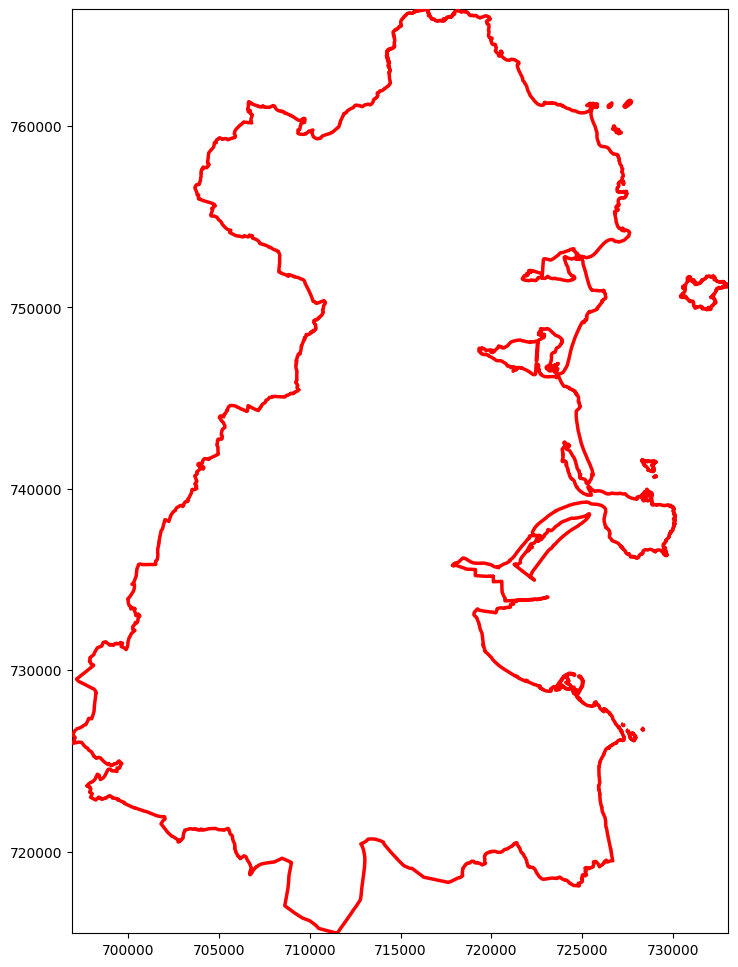

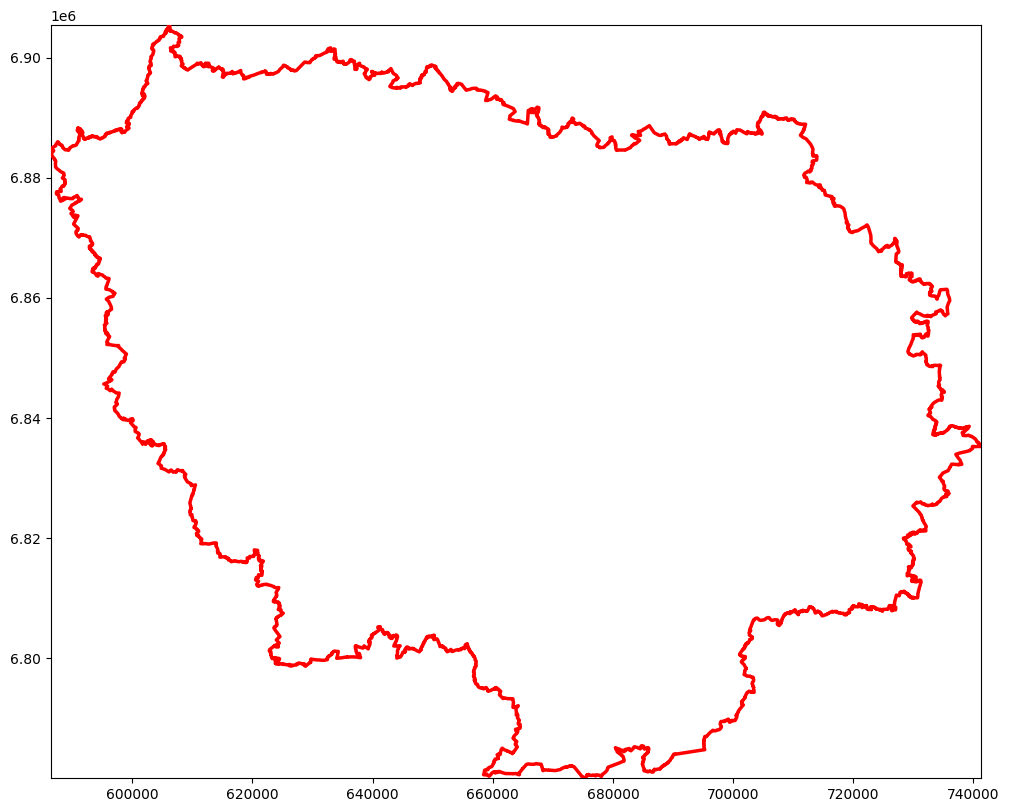

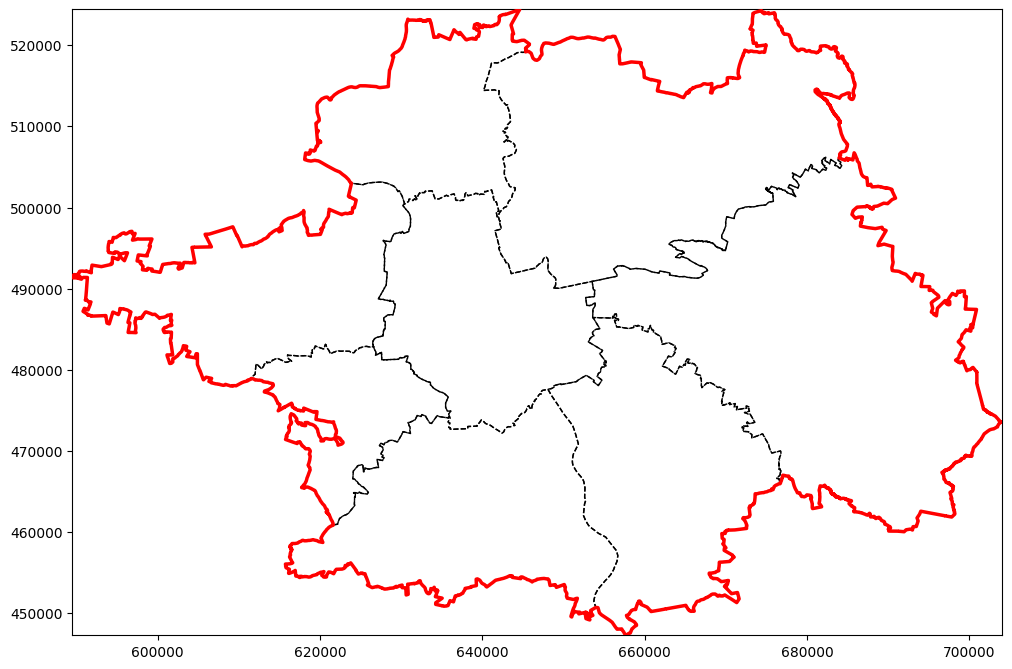

In [18]:
import matplotlib.pyplot as plt

def generate_coverage_maps(city: str):
    print(f"--- Generating Coverage Map: {city} ---")
    city_dir = OUT_DIR / city
    spatial_dir = city_dir / 'spatial'
    gtfs_norm_dir = city_dir / 'gtfs_normalized'
    
    # Load Normalized Stops
    stops_path = gtfs_norm_dir / 'stops.csv'
    if not stops_path.exists():
        print(f"[{city}] Stops not found, skipping map.")
        return
    
    stops_df = pd.read_csv(stops_path)
    gdf_stops = gpd.GeoDataFrame(
        stops_df,
        geometry=gpd.points_from_xy(stops_df.stop_lon, stops_df.stop_lat),
        crs='EPSG:4326'
    )
    
    target_crs = CITY_CFG[city]['crs_metric']
    gdf_stops_metric = gdf_stops.to_crs(target_crs)
    
    # Load main spatial layer (Zones/Grid)
    spatial_report_path = city_dir / 'spatial_report.json'
    spatial_rep = {}
    if spatial_report_path.exists():
        spatial_rep = json.loads(spatial_report_path.read_text(encoding='utf-8'))

    # Configure Plot Style (Light Theme)
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.set_facecolor('white') # Ensure white background

    # Plot Boundary if exists
    boundary_path = CITY_CFG[city].get('boundary_path')
    if boundary_path and boundary_path.exists():
        gdf_boundary = gpd.read_file(boundary_path).to_crs(target_crs)

        # 4. Black dashed line for sub-regions (original features)
        # Use plot() with facecolor='none' to draw polygon outlines correctly
        gdf_boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1, linestyle='--', zorder=4, label='Admin Regions')

        # 3. Red color for outer boundary (dissolved union)
        gdf_outer = gdf_boundary.dissolve()
        gdf_outer.boundary.plot(ax=ax, color='red', linewidth=2.5, zorder=5, label='Study Area Boundary')

        # Set limits
        minx, miny, maxx, maxy = gdf_outer.total_bounds
        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)

    # Plot layers (Grid/Zones) as background context
    plotted_layers = []
    if spatial_rep:
        for layer_name, info in spatial_rep.get('layers', {}).items():
            metric_gj = info['written']['metric_geojson']
            gdf_layer = gpd.read_file(metric_gj)
            # Very light grey for context layers
            gdf_layer.plot(ax=ax, color='gray', alpha=0.1, edgecolor='lightgray', linewidth=0.3, zorder=1)
            plotted_layers.append(layer_name)

    # 1. Plot filtered stops (Blue)
    # The 'gdf_stops_metric' are already filtered by process_city_gtfs -> filter_gtfs_by_polygon
    gdf_stops_metric.plot(ax=ax, markersize=3, color='blue', alpha=0.6, label='Valid GTFS Stops', zorder=3)

    ax.set_title(f"{city.upper()} Coverage Analysis", fontsize=14)
    ax.legend(loc='upper right')
    ax.axis('off')
    
    out_png = city_dir / 'coverage_map.png'
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"[{city}] Map saved to {out_png}")

for city in CITY_CFG:
    try:
        generate_coverage_maps(city)
    except Exception as e:
        print(f"Error generating map for {city}: {e}")
